# 1.Objetivo & Introdução


This project aims to help develop the ability to interpret statistical results in regression analyses.


To this end, regression models (GLMs) will be implemented to analyze the association between different risk factors and the chance of developing coronary heart disease (CHD) on the public dataset *framingham* [(kaggle.com)](https://www.kaggle.com/datasets/aasheesh200/framingham-heart-study-dataset).

---
### About the Problem:

Cardiovascular diseases are the leading cause of death in the world: more people die each year from these illnesses than from any other cause. It is estimated that **17.9 million** people died from cardiovascular diseases in 2019, representing 32% of all deaths globally [(who.int)](https://www.who.int/en/news-room/fact-sheets/detail/cardiovascular-diseases-(cvds).


Performing a preventive diagnosis of cardiovascular disease risk helps specialists make decisions about the treatment and advice they will give their patients.

# 2.EDA


---

We will try to understand the distribution of the data, assess the presence of possible correlations between variables and the relationship between risk factors and our target variable (TenYearCHD).

## Loading the data

In [139]:
!pip install --upgrade kagglehub
!pip install imbalanced-learn

In [140]:
from imblearn.over_sampling import SMOTE

from scipy.special import inv_boxcox
from scipy.stats import boxcox, chi2, f_oneway, kruskal, percentileofscore
from scipy.stats.mstats import winsorize


from sklearn.calibration import calibration_curve
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix, classification_report
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler, PowerTransformer

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

import statsmodels.formula.api as smf
from statsmodels.genmod.families import Binomial
from statsmodels.genmod.families.links import Logit, Probit, CLogLog, Identity
from statsmodels.genmod.generalized_linear_model import SET_USE_BIC_LLF

import kagglehub
import os
import math
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

import numpy as np
import pandas as pd
import patsy

In [141]:

path = kagglehub.dataset_download("aasheesh200/framingham-heart-study-dataset")

print("Path to dataset files:", path)

files_in_path = os.listdir(path)

print("Files inside the path:")
for file_name in files_in_path:
    print(file_name)

Path to dataset files: /root/.cache/kagglehub/datasets/aasheesh200/framingham-heart-study-dataset/versions/1
Files inside the path:
framingham.csv


In [142]:
df = pd.read_csv(path+'/framingham.csv')
df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


## Exploring the variables

Let's evaluate the balance between the target classes: Presence or Absence of risk of the disease.

### Distribution of Target Variable 'TenYearCHD'

Text(0, 0.5, 'Percentage')

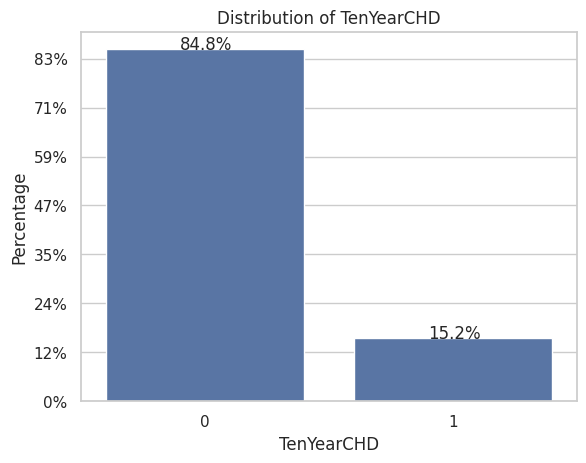

In [143]:

ax = sns.countplot(data=df, x='TenYearCHD')

for p in ax.patches:
    height = p.get_height()
    total = len(df['TenYearCHD'])
    percentage = '{:.1f}%'.format(100 * height / total)
    x = p.get_x() + p.get_width() / 2 - 0.1  # Adjust x position for label
    y = p.get_y() + p.get_height()          # Adjust y position for label
    ax.annotate(percentage, (x, y), size=12)  # Annotate with percentage label

ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=total))

ax.set_title('Distribution of TenYearCHD')
ax.set_xlabel('TenYearCHD')
ax.set_ylabel('Percentage')

We can see right from the start that the target variable, TenYearCHD, is not balanced within the dataset. This imbalance in the target class is an important characteristic that should guide the analysis and evaluation of the model, requiring some care:


1.   **Accuracy as a limited metric:** if we assume a model that classifies all samples as negative, we would already have 85% accuracy, and even then it would be a useless model for identifying positive cases. Looking only at this metric can lead to misleading conclusions.
2.  Reflect on the context of the problem and assess which metric best suits the needs of the application. The choice of classes has different impacts in this case.
3. There are techniques to minimize the impact of class imbalance, such as SMOTE (*Synthetic Minority Oversampling Technique*), which balances the distribution of classes by randomly increasing the examples of the minority class. It generates new virtual training data through linear interpolation.

Let's assume a healthcare scenario: It would be very bad for a patient to receive a false negative diagnosis, i.e. to have the risk of developing the condition and not know about it in order to take preventative measures in their life. It is therefore important to evaluate the predictive capacity of a model for this problem using an analysis metric that can weight false-negative cases, such as the *recall* or *f-score*.

Suggested reading:

- [Google ML Concepts: Classification](https://developers.google.com/machine-learning/crash-course/classification/accuracy-precision-recall)
- [SMOTE](https://www.jair.org/index.php/jair/article/view/10302)
- [Sklearn](https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.SMOTE.html)


### Distribution of Continuous Variables


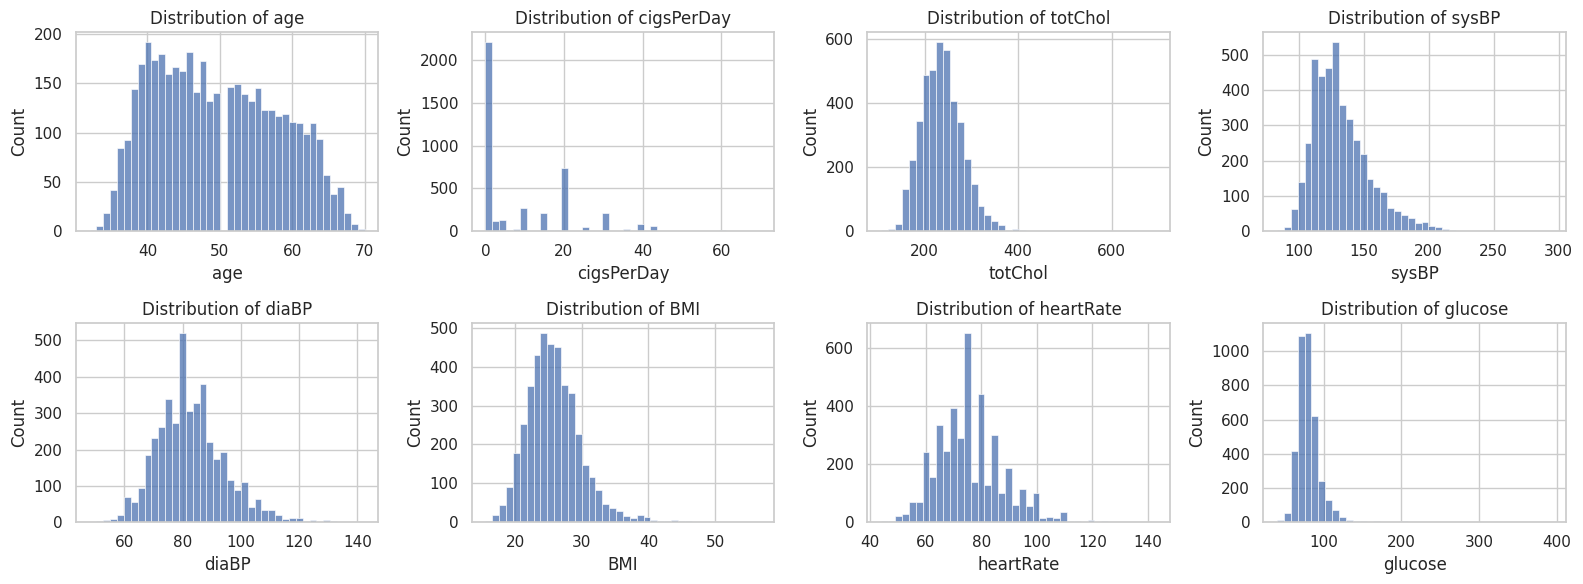

In [144]:

columns = ['age', 'cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']

fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(16, 6))
axes = axes.flatten()  # Flatten the axes array for easier iteration

for i, col in enumerate(columns):
    sns.histplot(data=df, x=col, bins=40, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

In the distributions of the continuous variables presented, we can see the presence of extreme values in several of them, such as 'cigsPerDay', 'glucose' and 'totChol'. This indicates that we should be careful about the presence of outliers in the data.

Most of the distributions show asymmetry, with curves slightly shifted to the left, suggesting a predominance of values concentrated in smaller intervals and some long tails for larger values. For example, the 'glucose' variable shows a marked concentration at low values, while 'cigsPerDay' has a large number of observations at zero, possibly indicating non-smoking individuals.

The variables 'sysBP', 'diaBP' and 'BMI' stand out for having distributions closer to a normal curve, which can facilitate analysis based on assumptions of normality. However, even for these variables, it is important to consider the impact of outliers in order to avoid bias in statistical or predictive models.


### Distribution of Nominal Variables

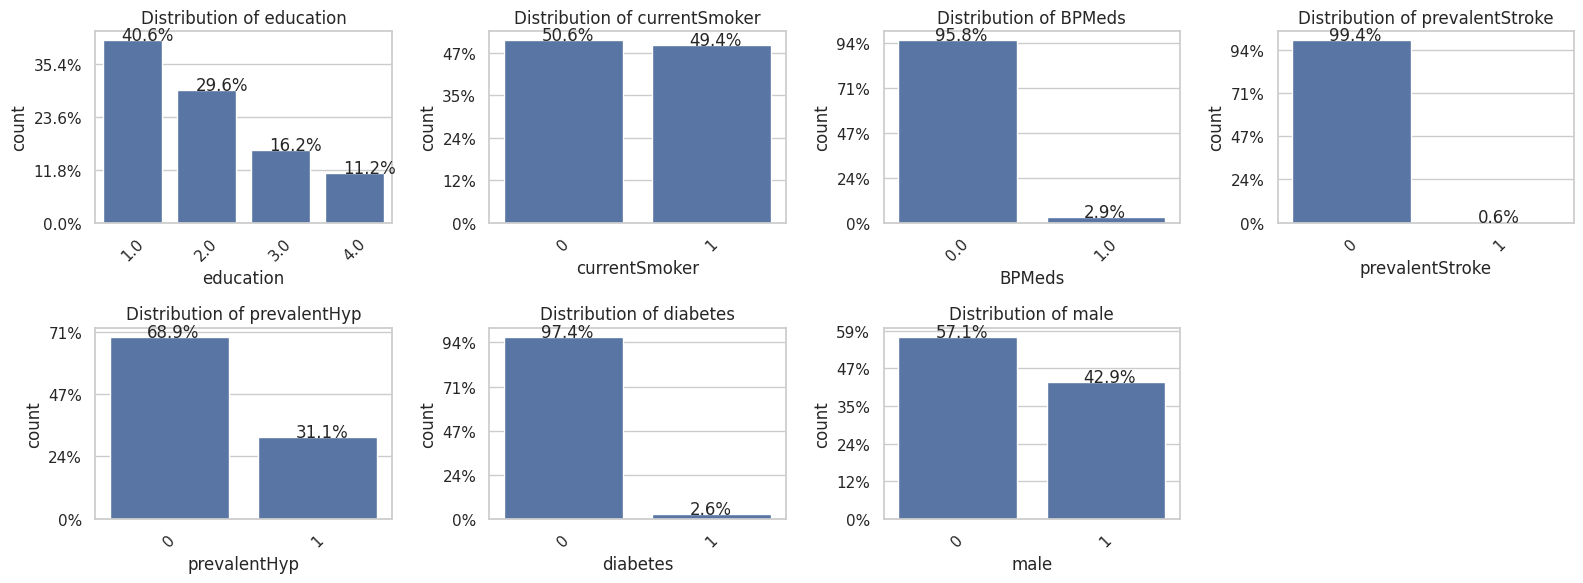

In [145]:


nominal_cols = ["education", "currentSmoker", "BPMeds", "prevalentStroke", "prevalentHyp", "diabetes", 'male']

num_plots = len(nominal_cols)
num_cols = 4
num_rows = math.ceil(num_plots / num_cols)

fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(16, 6))

# Flatten the axes array for easier iteration
# If there's only one plot, axes won't be an array, so we handle it separately
if num_plots == 1:
    axes = [axes]  # Wrap in a list if there's only one plot
else:
    axes = axes.flatten()

# Loop through each column and create a bar plot using Seaborn
for i, col in enumerate(nominal_cols):
    ax = sns.countplot(data=df, x=col, ax=axes[i])

    # Add percentage labels
    for p in ax.patches:
        height = p.get_height()
        total = len(df[col])
        percentage = '{:.1f}%'.format(100 * height / total)
        x = p.get_x() + p.get_width() / 2 - 0.15  # Adjust x position for label
        y = p.get_y() + p.get_height()            # Adjust y position for label
        ax.annotate(percentage, (x, y), size=12)  # Annotate with percentage label

    axes[i].set_title(f'Distribution of {col}')
    axes[i].tick_params(axis='x', rotation=45)  # Rotate x-axis labels for better readability
    axes[i].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=len(df[col])))  # Format y-axis as percentage

# Remove empty subplots (if any)
if num_plots < len(axes):
    for i in range(num_plots, len(axes)):
        fig.delaxes(axes[i])

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

By analyzing the distributions of categorical variables, we can better understand the profile of the database.

For example, the extremely low proportions for some categories, such as 'BPMeds', 'diabetes' and 'prevalentStroke', indicate that these events are rare in the sample. Therefore, these variables may not have such a significant weight in predicting outcomes, depending on the model used.

Another noteworthy point is the balanced distribution between smokers and non-smokers, which may be a relevant characteristic when analyzing the impact of smoking on health. The variables related to hypertension ('prevalentHyp') and gender ('male') show a more unequal distribution, with a prevalence of people without hypertension (68.9%) and a slight predominance of women (57.1%) in the sample.


### Relationship between dependent and independent variables

### Distribution of Continuous Variables by TenYearCHD


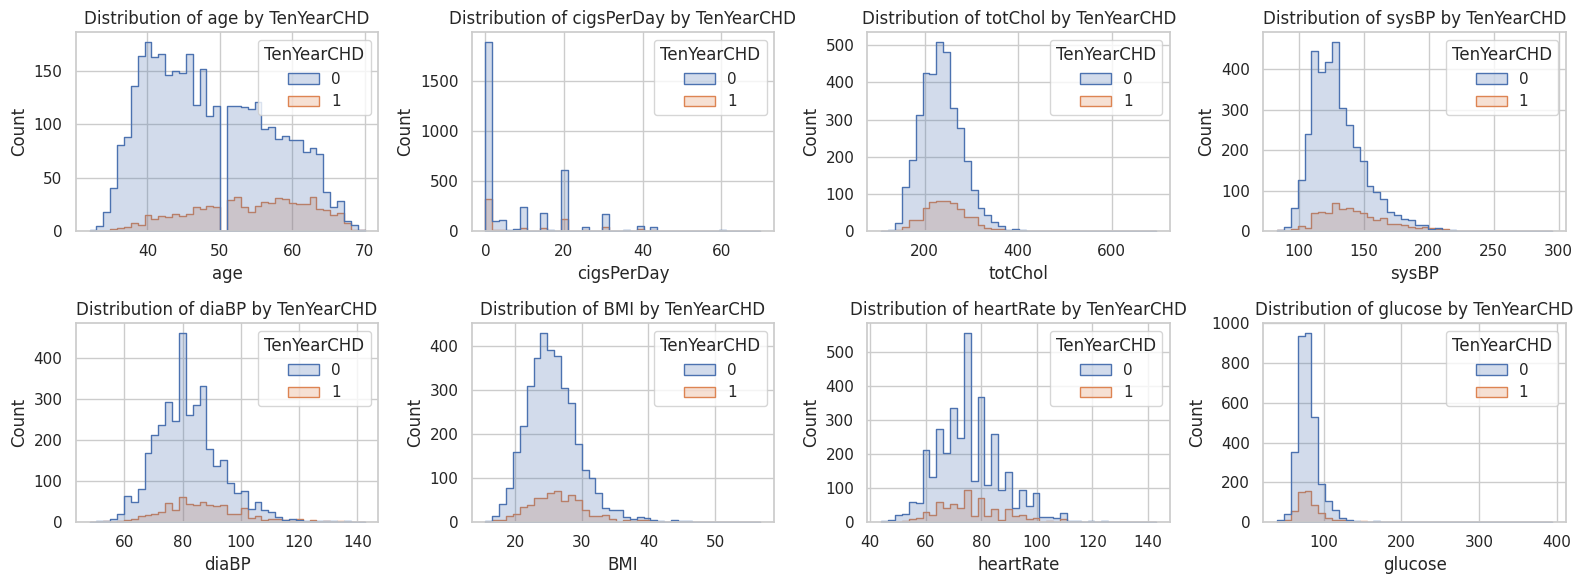

In [146]:
columns = ['age', 'cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']

fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(16, 6))
axes = axes.flatten()  # Flatten the axes array for easier iteration

for i, col in enumerate(columns):
    sns.histplot(data=df, x=col, bins=40, hue='TenYearCHD', element='step', ax=axes[i]) # Dividir por 'TenYearCHD'
    axes[i].set_title(f'Distribution of {col} by TenYearCHD') # Alterar o título

plt.tight_layout()
plt.show()

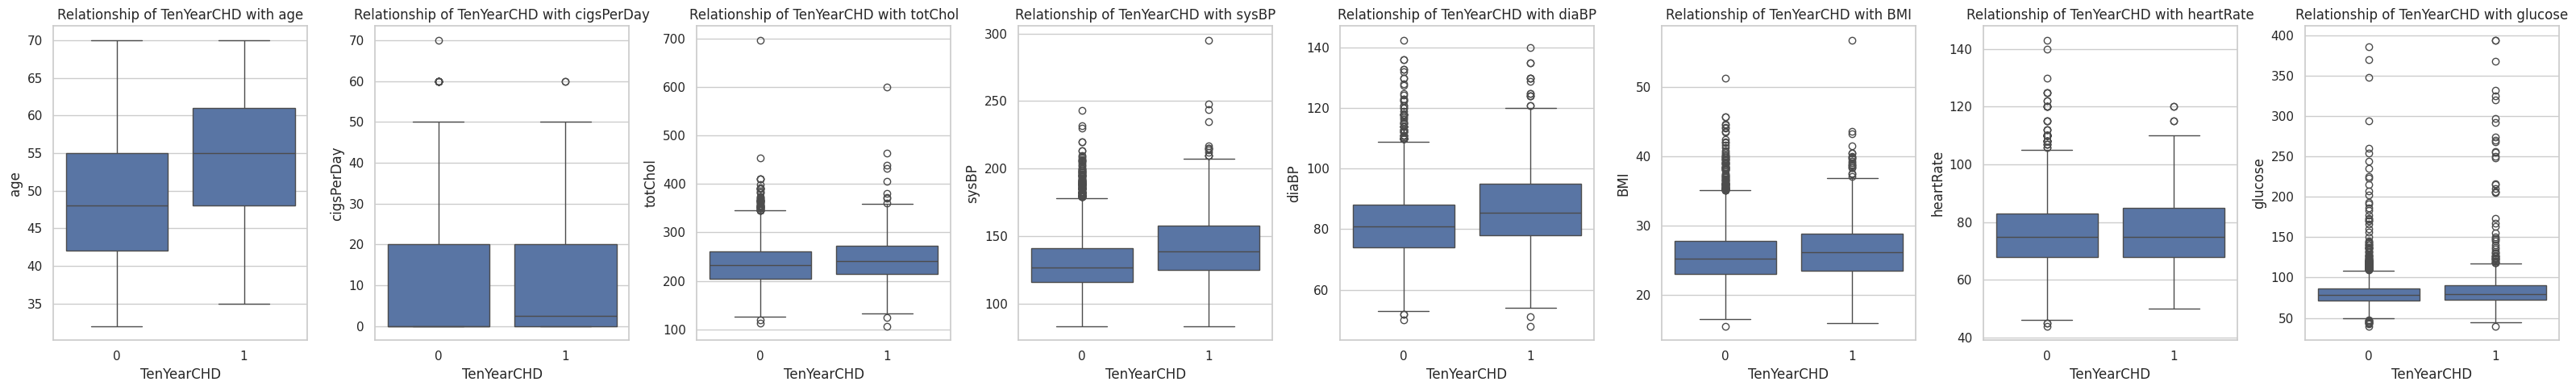

In [147]:
columns = ['age', 'cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']
fig, axes = plt.subplots(nrows=1, ncols=len(columns), figsize=(32, 5))
axes = axes.flatten()  # Flatten the axes array for easier iteration

for i, col in enumerate(columns):
    sns.boxplot(x='TenYearCHD', y=col, data=df, ax=axes[i])
    axes[i].set_title(f'Relationship of TenYearCHD with {col}')

plt.tight_layout()
plt.show()

Analyzing the continuous variables in relation to the marking of the disease, we identified clear patterns of differentiation, as in the case of the variable 'age', where positive individuals (1) tend to be older. The same behavior is observed in 'sysBP', 'diaBP' and, more subtly, in 'BMI'. This suggests that these variables have the potential to discriminate well between groups and are promising candidates as predictors.

The boxplots also revealed the presence of outliers in variables such as 'glucose' and blood pressure. These extreme values can impact models and analyses, and it is necessary to assess whether they are representative or just noise.

It is worth noting that the blood pressure variables ('sysBP' and 'diaBP') are probably correlated, which may be relevant to avoid multicollinearity in linear models. In addition, a more in-depth analysis of the distribution of 'BMI' and statistical tests can confirm whether the differences observed are significant, even when they are less obvious.

Finally, as age is strongly related to cardiovascular risk, it is important to consider adjustments to prevent this bias from dominating the analysis, ensuring that other relevant factors are also taken into account


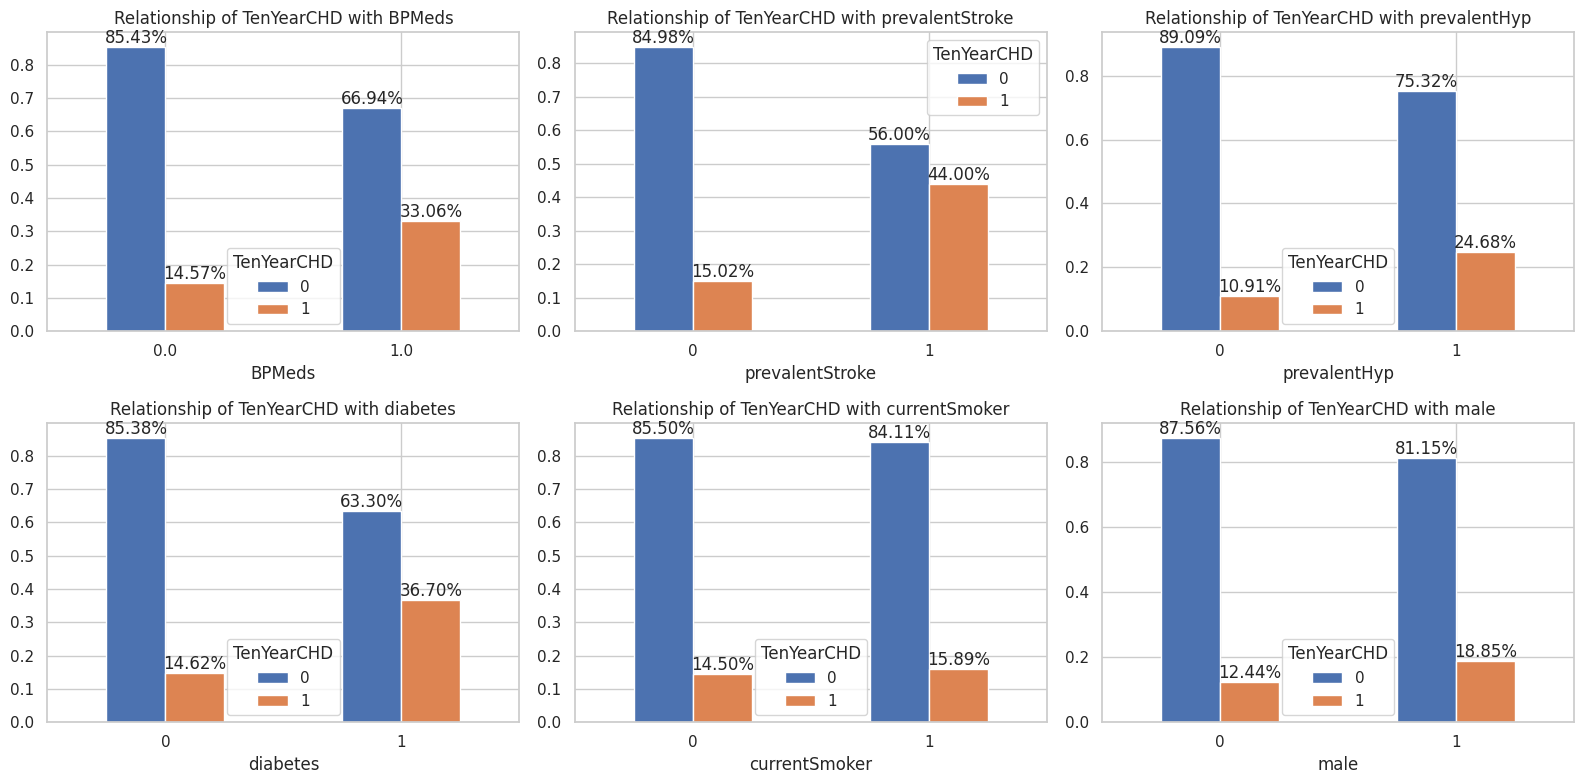

In [148]:

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(['BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes', 'currentSmoker', 'male']):
    ct = pd.crosstab(df[col], df['TenYearCHD'], normalize='index')
    ax = ct.plot(kind='bar', ax=axes[i], rot=0)  # Use the current subplot
    ax.set_title(f'Relationship of TenYearCHD with {col}')

    for p in ax.patches:
        height = p.get_height()
        ax.annotate(f'{(height*100):.2f}%', (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', xytext=(0, 0), textcoords='offset points')

plt.tight_layout()
plt.show()

The analysis of categorical variables revealed important patterns in the relationship with the risk of heart disease (TenYearCHD). Marker variables such as BPMeds, prevalentStroke, diabetes and prevalentHyp show a significant increase in the proportion of the positive class in their presence, standing out as potential predictors.


However, it is important to note that BPMeds, prevalentStroke and diabetes have a low frequency in the dataset (3%, 0.6% and 2.6%, respectively), which may limit their practical contribution to modeling. On the other hand, prevalentHyp, which is more representative, showed an increase from 10.91% to 24.68% in the prevalence of the positive class, reinforcing its relevance.

Among the more balanced variables, male gender stood out, with an increase from 12.44% to 18.85% in the prevalence of the positive class, indicating a slight association with greater risk. On the other hand, current smoking (currentSmoker) showed a more subtle increase, suggesting that, in isolation, it may not be a strong discriminator in the context analyzed.

---

These results reflect risk factors already known in the medical literature, i.e. the presence of previous medical conditions may be a factor that increases the risk of developing coronary heart disease. But they highlight the importance of exploring correlations and adjusting the analysis for the low representativeness of some marker variables.


### Analysis of the relationship between risk and var education

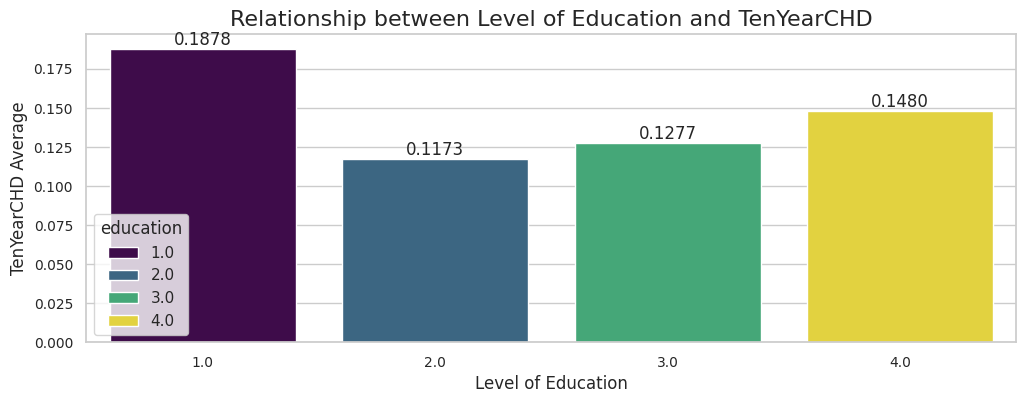

In [149]:
education_chd_means = df.groupby('education')['TenYearCHD'].mean().reset_index()

sns.set(style="whitegrid")

plt.figure(figsize=(12, 4))
ax = sns.barplot(x='education', y='TenYearCHD', hue='education', data=education_chd_means, palette='viridis')

for container in ax.containers:
    ax.bar_label(container, fmt='%.4f', label_type='edge')

plt.title('Relationship between Level of Education and TenYearCHD', fontsize=16)
plt.xlabel('Level of Education', fontsize=12)
plt.ylabel('TenYearCHD Average', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.show()

Based on the graph, it is clear that the relationship between the level of education and the average risk of TenYearCHD does not follow a clear linear pattern. Here are some important points to consider:

1. highest average for education = 1:

 - The lowest level of education (1) has the highest average risk. This may indicate that individuals with less education are more exposed to risk factors associated with the disease.
2. Inconsistent increase between education = 2, 3, 4:

 - Between levels 2, 3 and 4, there is an increase in average risk, but not proportionally. This suggests that the difference between the levels may not be purely ordinal (equal distances between categories).


### Correlations

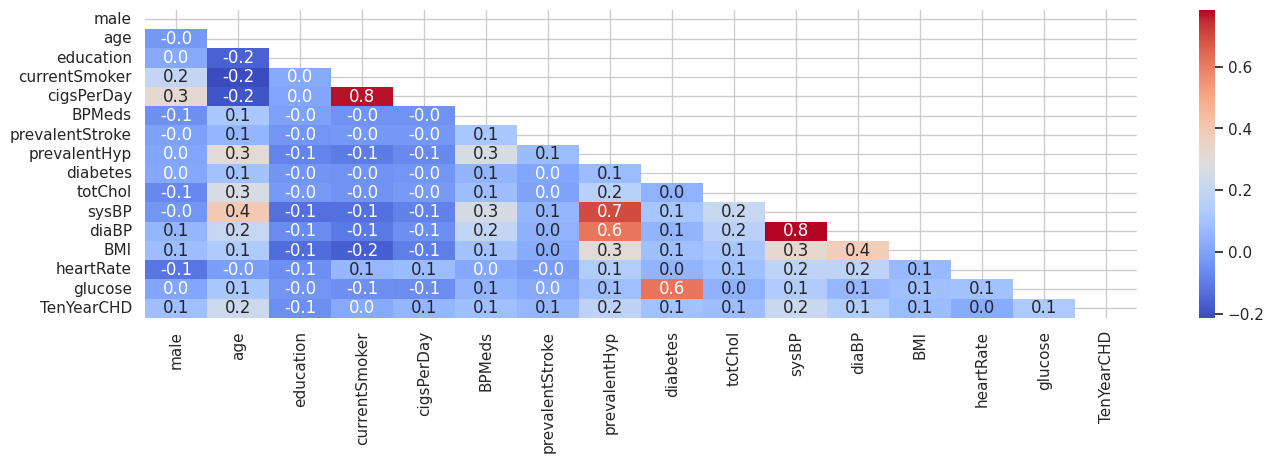

In [150]:
corr = df.corr()
plt.figure(figsize=(16, 4))

sns.heatmap(corr, annot=True, fmt='.1f', cmap='coolwarm', mask=np.triu(corr))

plt.show()

The observed correlations are expected and make sense:
- (cigsPerDay, currentSmoker): Smokers tend to smoke more cigarettes.
- (sysBP, prevalentHyp) and (diaBP, prevalentHyp): Pre-existing hypertension reflects high blood pressure values at both the maximum (systolic) and minimum (diastolic) thresholds.
- (glucose, diabetes): Diabetes is associated with high blood glucose levels.
- (diaBP, sysBP): Systolic and diastolic blood pressures are intrinsically related.

To assess the impact of correlations on the modeling process, we can analyze some metrics:
- Multicollinearity: Use Variance Inflation Factor (VIF) to identify redundant variables. The VIF provides an index that measures the degree to which the variance of an estimated regression coefficient increases due to collinearity.
- Evaluate the significance of the fit of the model with the variables and their interactions.


Multicollinearity occurs when two or more explanatory variables are strongly correlated with each other. This can be problematic because, instead of each variable bringing new and unique information, they “repeat” data that is already being captured by others. As a result, the model's coefficients can become unstable and difficult to interpret.

To identify and quantify this problem, we use a metric called VIF (Variance Inflation Factor).


### Analyzing Interactions


Interaction plots are powerful visual tools that help us understand how two independent variables influence a dependent variable together. They are especially useful when we want to explore whether the effect of one variable on the outcome changes depending on the level of another variable.

---

**How to read an interaction graph?

Reading an interaction graph is simple, but requires attention to a few key points:
1. Observe the lines (their slopes and distances):

  - Parallel lines suggest that there is no significant interaction. In other words, the effect of one variable on the outcome is the same, regardless of the other.
  - Lines that cross or have very different slopes indicate significant interaction. This suggests that the impact of one variable depends on the state of the other.

2. Consider the confidence intervals (shaded areas):
  - They indicate the uncertainty in the estimate of the mean. Overlap between intervals suggests that the differences may not be statistically significant.


[R-Project](https://cran.r-project.org/web/packages/sjPlot/vignettes/plot_interactions.html)


In [151]:
def interaction_plot(df, independent_vars, target_var, comparison_var):
    """
    Creates interaction plots to visualize the relationship between independent variables,
    a target variable, and a comparison variable.

    Args:
        df (pd.DataFrame): The DataFrame containing the data.
        independent_vars (list): A list of independent variable names.
        target_var (str): The name of the target variable.
        comparison_var (str): The name of the comparison variable.
    """
    num_plots = len(independent_vars)
    num_cols = 4
    num_rows = math.ceil(num_plots / num_cols)

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(16, 4 * num_rows))
    axes = axes.flatten()

    for i, var in enumerate(independent_vars):
        sns.lineplot(
            data=df,
            x=var,
            y=target_var,
            hue=comparison_var,
            marker='o',
            palette='Set1',
            ax=axes[i]
        )

        axes[i].set_title(f'{var} and {comparison_var} on {target_var}', fontsize=12)
        axes[i].set_ylabel(f'Mean of {target_var}', fontsize=10)
        axes[i].set_xlabel(var, fontsize=10)
        axes[i].legend(title=f'{comparison_var}', fontsize=8)
        axes[i].grid(True)

    if num_plots < num_rows * num_cols:
        for i in range(num_plots, num_rows * num_cols):
            fig.delaxes(axes[i])

    plt.tight_layout()
    plt.show()

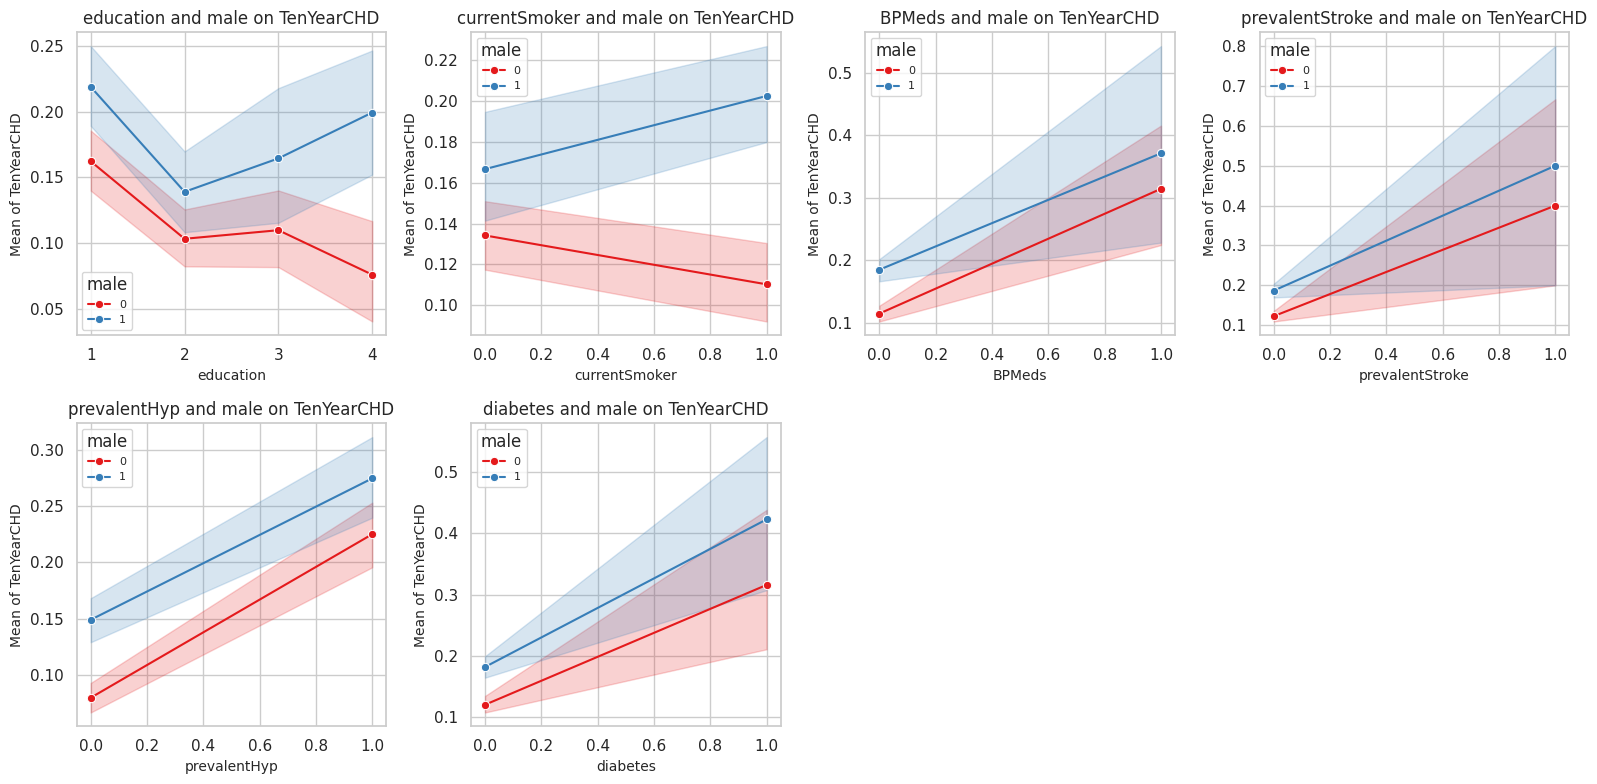

In [152]:
independent_vars = [
    'education', 'currentSmoker','BPMeds',
    'prevalentStroke', 'prevalentHyp', 'diabetes'
]
interaction_plot(df, independent_vars, 'TenYearCHD', 'male')

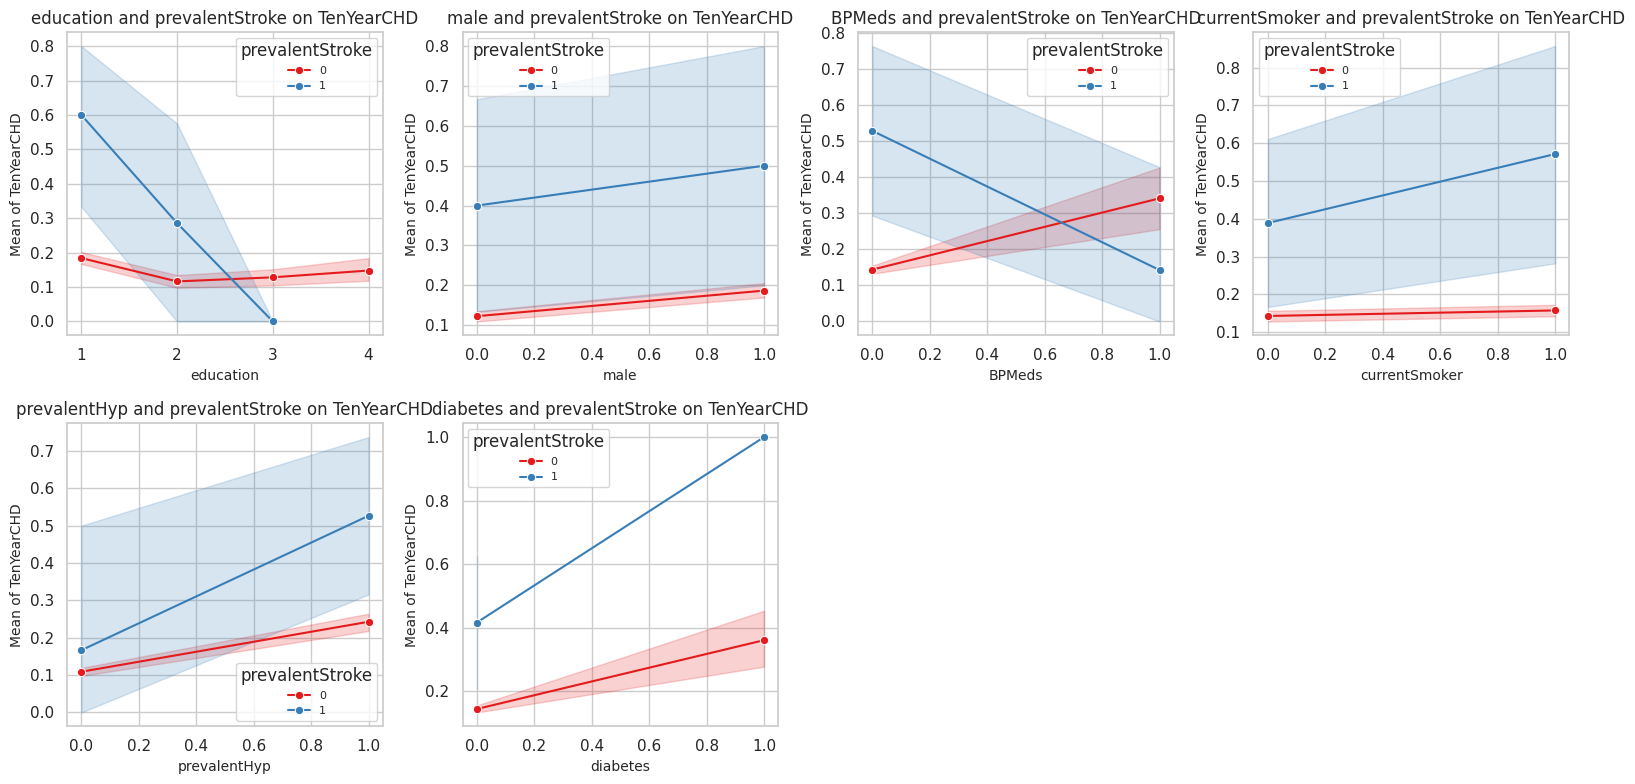

In [153]:
independent_vars = [
    'education', 'male','BPMeds', 'currentSmoker',
    'prevalentHyp', 'diabetes'
]
interaction_plot(df, independent_vars, 'TenYearCHD', 'prevalentStroke')

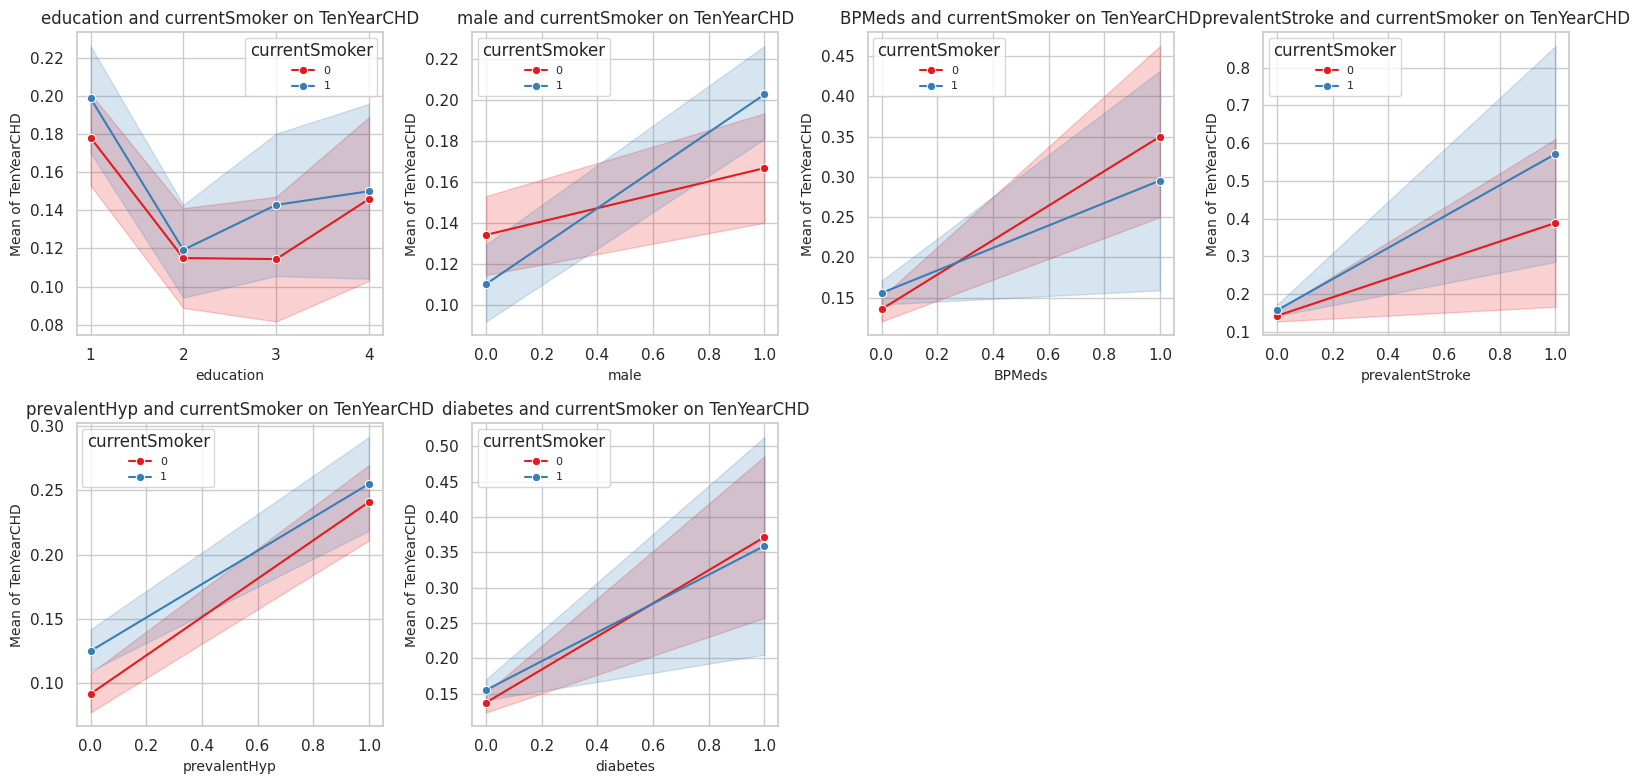

In [154]:
independent_vars = [
    'education', 'male','BPMeds',
    'prevalentStroke', 'prevalentHyp', 'diabetes'
]
interaction_plot(df, independent_vars, 'TenYearCHD', 'currentSmoker')

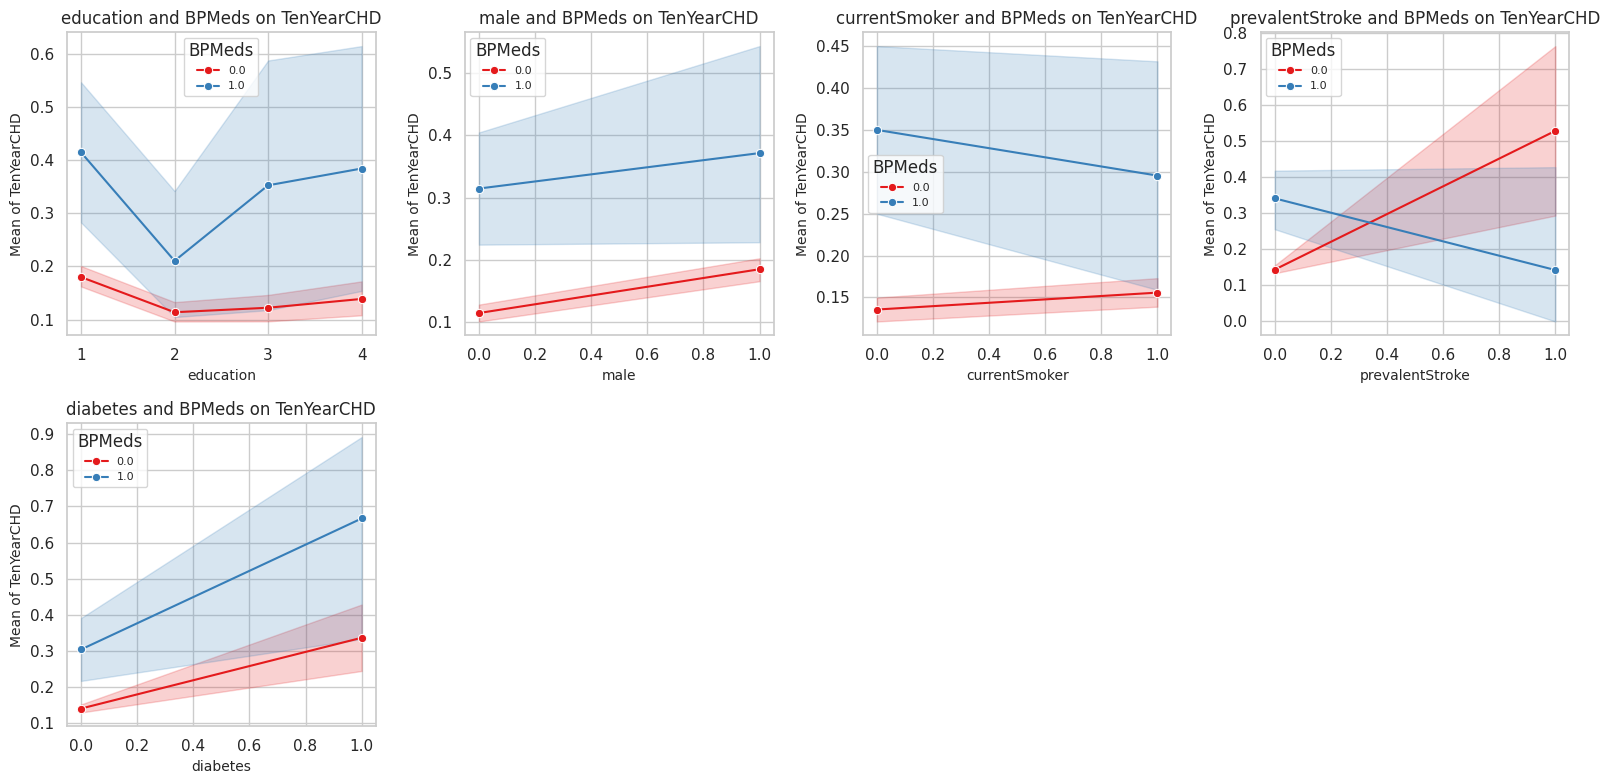

In [155]:
independent_vars = [
    'education', 'male','currentSmoker',
    'prevalentStroke', 'diabetes'
]
interaction_plot(df, independent_vars, 'TenYearCHD', 'BPMeds')

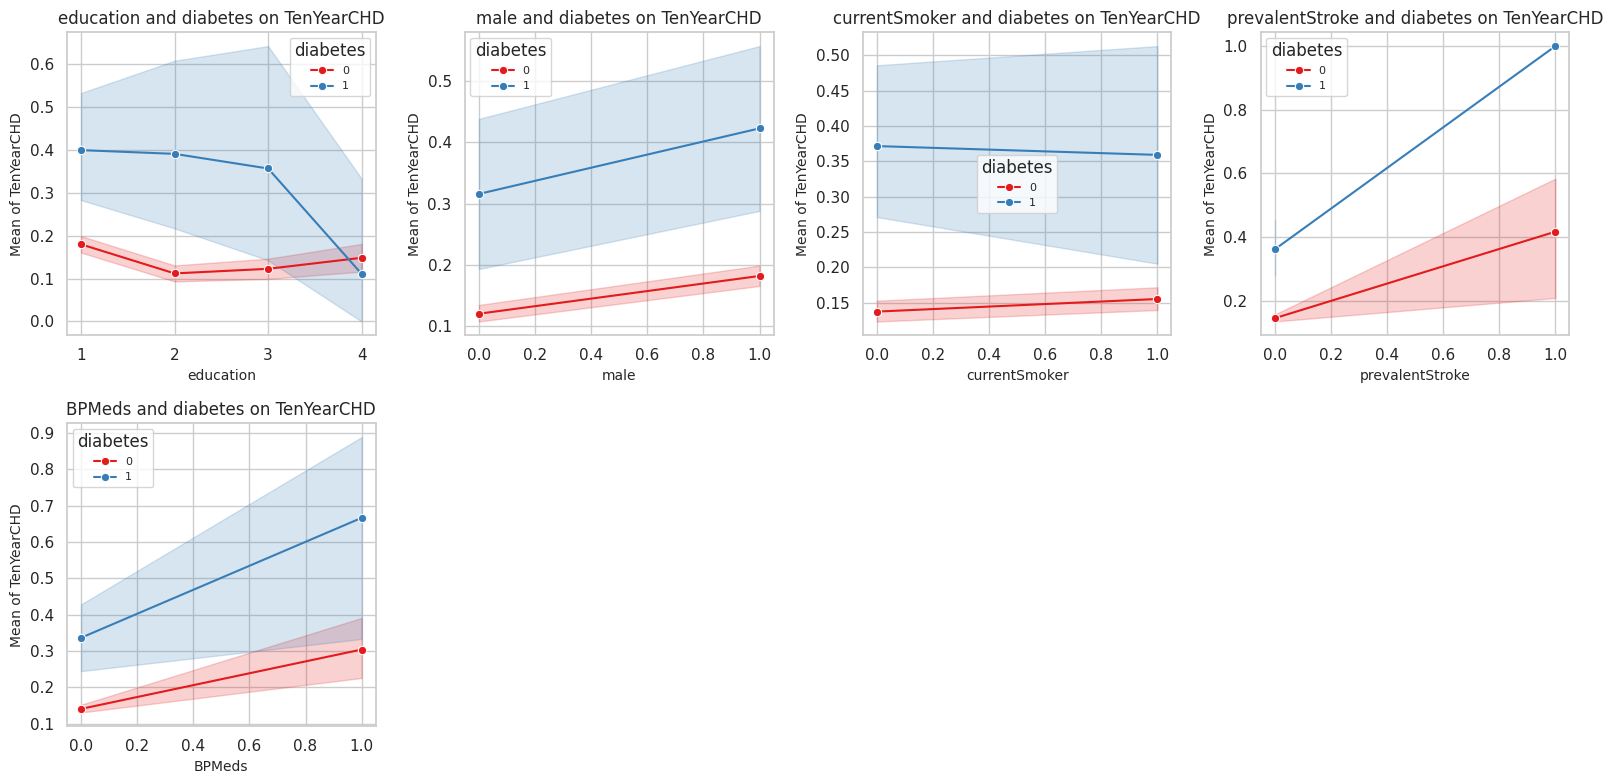

In [156]:
independent_vars = [
    'education', 'male','currentSmoker',
    'prevalentStroke',  'BPMeds'
]
interaction_plot(df, independent_vars, 'TenYearCHD', 'diabetes')

Let's explore some examples of the graphs generated:

1. Sex (male) and smoking:
  
  You can see that men (male = 1) have a higher risk of *TenYearCHD* compared to women (male = 0), but this effect is amplified for smokers. The lines are not parallel, indicating interaction.


2. Hypertension and smoking:

  Both smokers and non-smokers have an increased risk of *TenYearCHD* with prevalent hypertension (prevalentHyp). However, the risk is consistently higher for smokers at all levels of hypertension.

3. Education and prevalence of stroke:

  In individuals without stroke, the risk of *TenYearCHD* decreases as the level of education increases, indicating that higher education may be associated with a healthier lifestyle.
For individuals with stroke, the risk also decreases with higher education, but remains much higher compared to those without stroke.

4. Smoking and Stroke Prevalence:

  Smokers have a higher risk of *TenYearCHD* , even without stroke.
In smokers with stroke, the risk increases substantially.
Conclusion: Smoking exacerbates the effect of stroke on the risk of *TenYearCHD* , reinforcing the need for interventions to control/reduce smoking.


5. Blood Pressure Medications and Stroke Prevalence
  
  Without stroke, the use of blood pressure medication appears to slightly reduce the risk of *TenYearCHD*.
  With stroke, the use of pressure medications does not significantly reduce the risk of *TenYearCHD*, which may suggest that stroke overrides the benefits of medications. Conclusion: The interaction here reflects how the prevalence of stroke may partially counteract the positive effect of pressure treatments.



### Analyzing Data Linearity


Interpretation: If the probability of DAC does not grow steadily in the bins of values, it may be an indication of non-linearity.


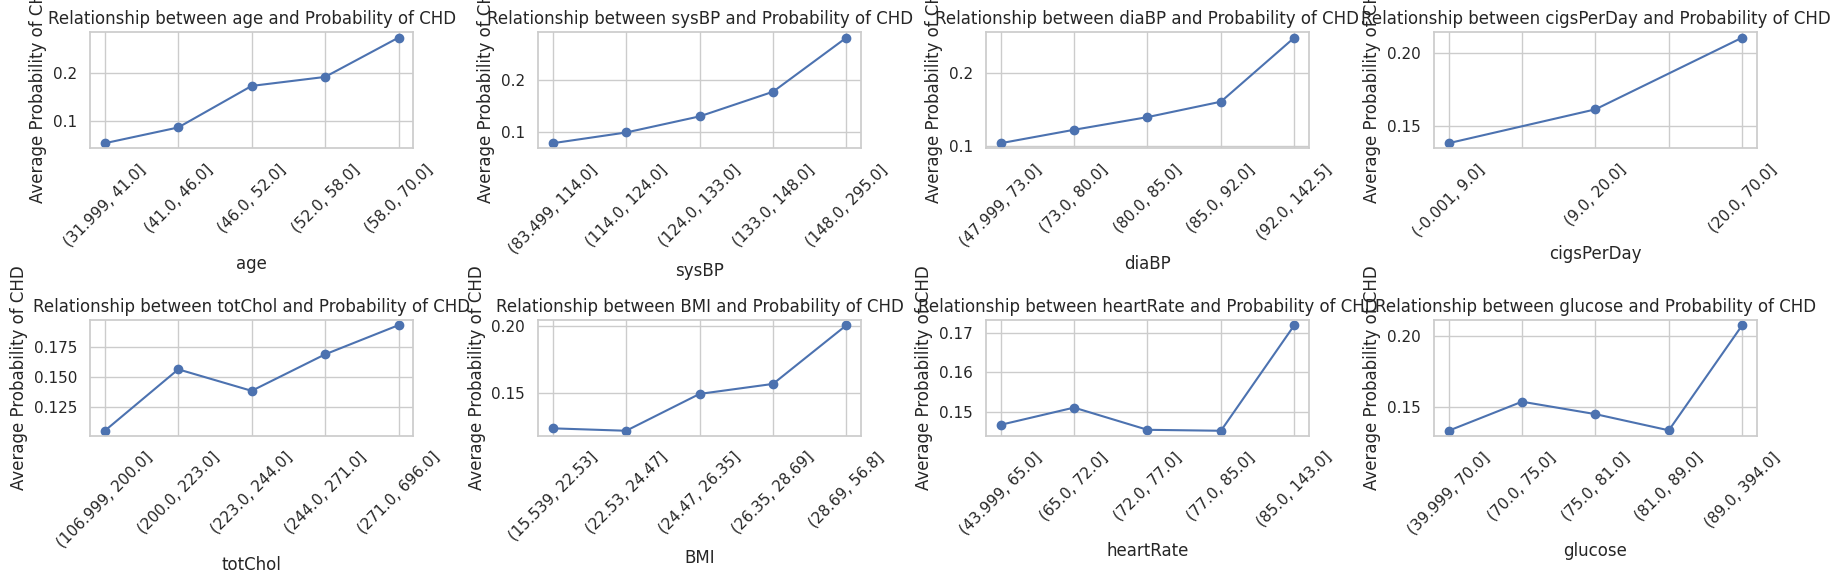

In [157]:
vars_continuas = ['age', 'sysBP', 'diaBP', 'cigsPerDay', 'totChol', 'BMI', 'heartRate', 'glucose']

num_bins = 5
df_bins = df.copy()

num_rows = 2
num_cols = 4

fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(18,6))


for i, var in enumerate(vars_continuas):
    row = i // num_cols
    col = i % num_cols

    df_bins[f"{var}_bin"] = pd.qcut(df_bins[var], q=num_bins, duplicates="drop")
    bin_means = df_bins.groupby(f"{var}_bin", observed=True)["TenYearCHD"].mean()

    ax = axes[row, col]
    bin_means.plot(marker="o", linestyle="-", color="b", ax=ax)

    ax.set_xlabel(var)
    ax.set_ylabel("Average Probability of CHD")
    ax.set_title(f"Relationship between {var} and Probability of CHD")
    ax.tick_params(axis='x', rotation=45)  # Rotate x-axis labels
    ax.grid(True)

plt.tight_layout()
plt.show()


We want to see if there are any gains from adding the quadratic terms

[LOESS plot](https://en.wikipedia.org/wiki/Local_regression)

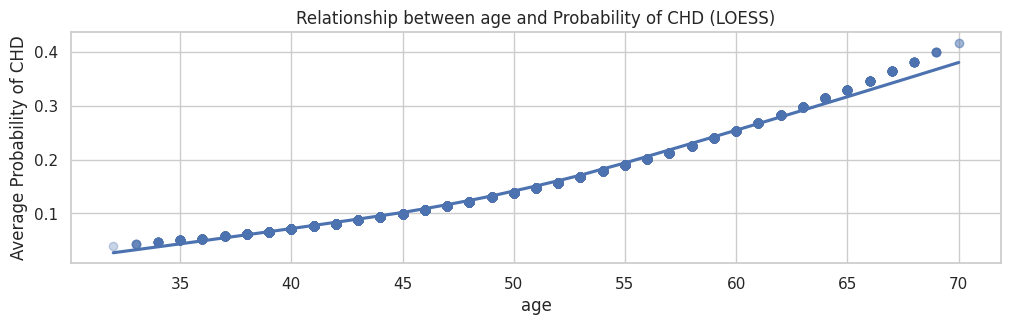

Variável: age
Estatística do Teste: 5.0464, p-valor: 0.0247



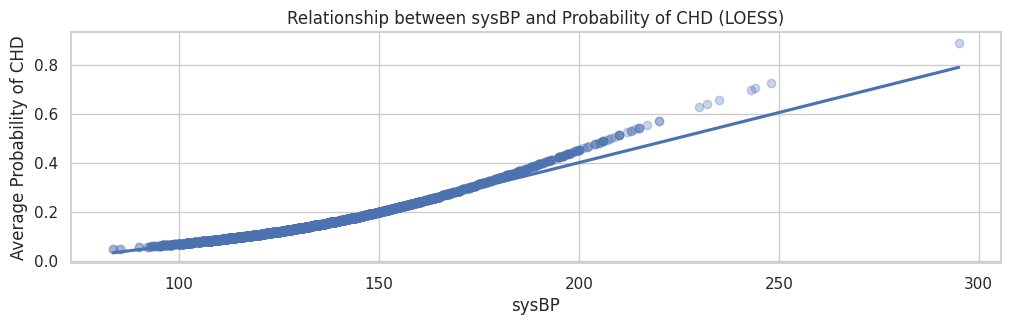

Variável: sysBP
Estatística do Teste: 0.5124, p-valor: 0.4741



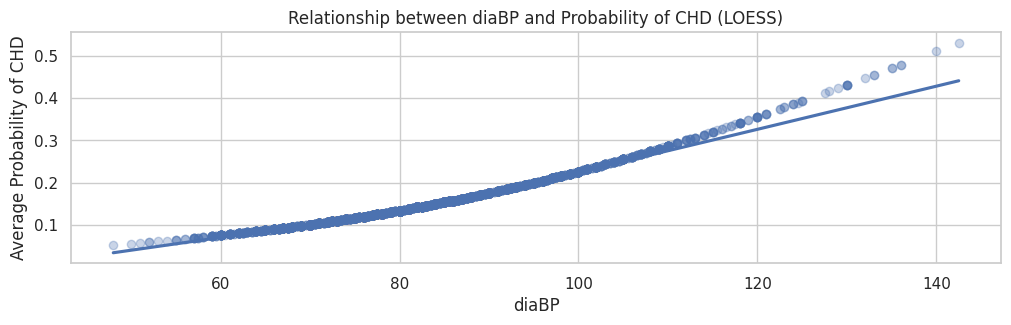

Variável: diaBP
Estatística do Teste: 4.9163, p-valor: 0.0266



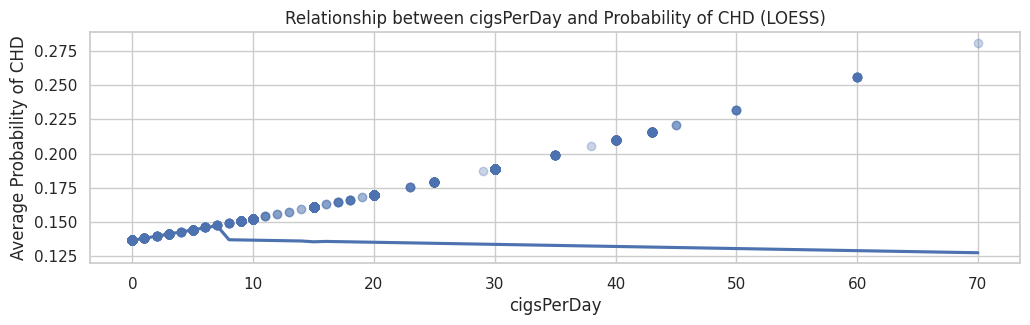

Variável: cigsPerDay
Estatística do Teste: 0.2637, p-valor: 0.6076



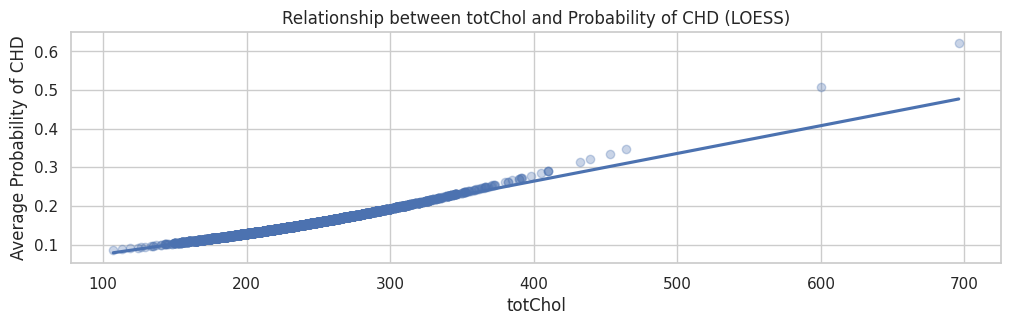

Variável: totChol
Estatística do Teste: 0.1665, p-valor: 0.6833



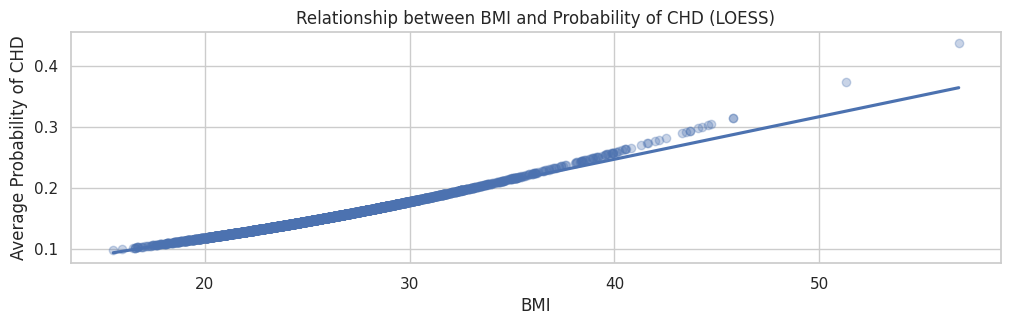

Variável: BMI
Estatística do Teste: 0.1432, p-valor: 0.7051



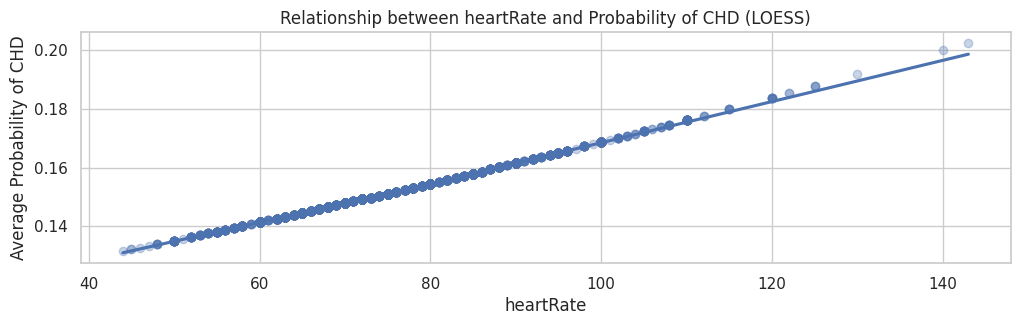

Variável: heartRate
Estatística do Teste: 0.0069, p-valor: 0.9339



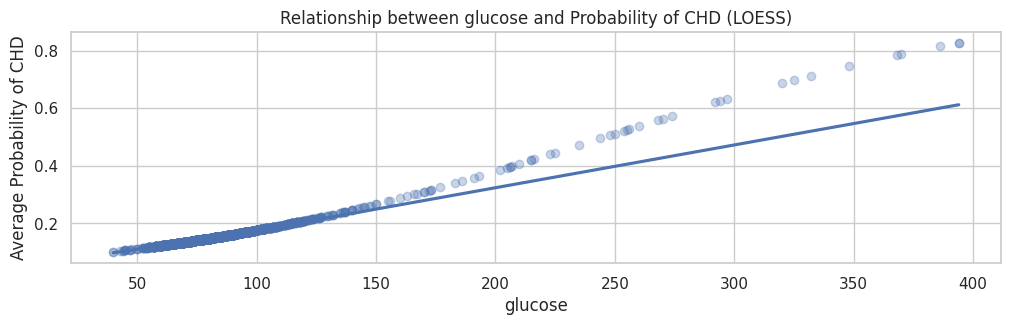

Variável: glucose
Estatística do Teste: 0.0403, p-valor: 0.8409



In [158]:
vars_to_analyze = ['age',  'sysBP', 'diaBP', 'cigsPerDay', 'totChol','BMI', 'heartRate', 'glucose' ]
df_copy = df.copy()

for var in vars_to_analyze:
    df_copy[var] = df_copy[var].replace([np.inf, -np.inf], np.nan)
    df_copy[var] = df_copy[var].fillna(df_copy[var].median())

    df_copy["prob_CHD"] = sm.Logit(df_copy["TenYearCHD"], sm.add_constant(df_copy[var])).fit(disp=0).predict()

    plt.figure(figsize=(12, 3))
    sns.regplot(x=var, y="prob_CHD", data=df_copy, lowess=True, scatter_kws={'alpha':0.3})
    plt.xlabel(var)
    plt.ylabel("Average Probability of CHD")
    plt.title(f"Relationship between {var} and Probability of CHD (LOESS)")
    plt.show()

    linear_model = smf.logit(f"TenYearCHD ~ {var}", data=df_copy).fit(disp=0)

    squared_model = smf.logit(f"TenYearCHD ~ {var} + I({var}**2)", data=df_copy).fit(disp=0)


    lr_stat = 2 * (squared_model.llf - linear_model.llf)
    p_value = chi2.sf(lr_stat, df=1)

    print(f"Variável: {var}")
    print(f"Estatística do Teste: {lr_stat:.4f}, p-valor: {p_value:.4f}\n")

## Data treatment

### Missing values

In [159]:

total_null_percentage = df.isnull().sum().sum() / (len(df) * len(df.columns)) * 100
print(f"Total percentage of null values: {total_null_percentage:.2f}%")


Total percentage of null values: 0.95%


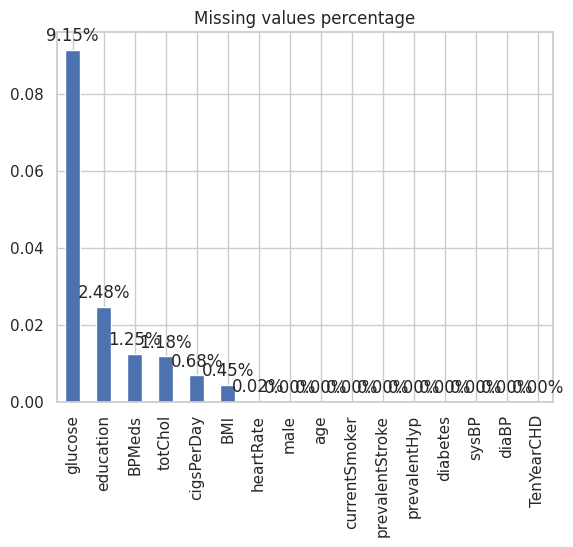

In [160]:
ax = df.isnull().mean().sort_values(ascending=False).plot(kind='bar', title='Missing values percentage')

for p in ax.patches:
    ax.annotate(f'{p.get_height():.2%}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')

### Missing values approach


---

- Continuos: Median - less sensitvie to outliers.
- Categorical: Mode.

In [161]:

def fill_missing_values(df, continuous_vars, categorical_vars):
  for col in continuous_vars:
    # df.loc[:, col] = df[col].fillna(df[col].mean())
    df.loc[:, col] = df[col].fillna(df[col].median())

  for col in categorical_vars:
    df.loc[:, col] = df[col].fillna(df[col].mode()[0])
  return df

In [162]:
continuous_vars = ['age', 'cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']
categorical_vars = ['education', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes', 'currentSmoker', 'male']

df = fill_missing_values(df, continuous_vars, categorical_vars)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4240 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4240 non-null   float64
 5   BPMeds           4240 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   int64  
 9   totChol          4240 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4240 non-null   float64
 13  heartRate        4240 non-null   float64
 14  glucose          4240 non-null   float64
 15  TenYearCHD       4240 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 530.1 KB


In [163]:
total_null_percentage = df.isnull().sum().sum() / (len(df) * len(df.columns)) * 100
print(f"Total percentage of null values: {total_null_percentage:.2f}%")

Total percentage of null values: 0.00%




### Transformation of categorical variables into dummies
---
- Transform the variable *education* into dummies variables because the relationship is not exactly linear.

In [164]:

def create_dummies(df, categorical_vars_with_dummies):
    df = pd.get_dummies(df, columns=categorical_vars_with_dummies, drop_first=True,dtype='int')
    return df

In [165]:
df = create_dummies(df, categorical_vars_with_dummies=['education'])

df = df.rename(columns={
    'education_2.0': 'education_2',
    'education_3.0': 'education_3',
    'education_4.0': 'education_4'
})
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   currentSmoker    4240 non-null   int64  
 3   cigsPerDay       4240 non-null   float64
 4   BPMeds           4240 non-null   float64
 5   prevalentStroke  4240 non-null   int64  
 6   prevalentHyp     4240 non-null   int64  
 7   diabetes         4240 non-null   int64  
 8   totChol          4240 non-null   float64
 9   sysBP            4240 non-null   float64
 10  diaBP            4240 non-null   float64
 11  BMI              4240 non-null   float64
 12  heartRate        4240 non-null   float64
 13  glucose          4240 non-null   float64
 14  TenYearCHD       4240 non-null   int64  
 15  education_2      4240 non-null   int64  
 16  education_3      4240 non-null   int64  
 17  education_4   

# 3.Modeling

## Initial Model Construction - Unrestricted

Model in principle with all the variables to serve as a reference for evaluating gains from transformations and adjustments

In [166]:
formula = """
TenYearCHD ~male + age + education_2 +education_3 +education_4 + currentSmoker + cigsPerDay + BPMeds +
       prevalentStroke + prevalentHyp + diabetes + totChol + sysBP +
       diaBP + BMI + heartRate + glucose
"""
# 1. Split into training and test
y, X = patsy.dmatrices(formula, data=df, return_type='dataframe')
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

# 2. Fitting the model
model = sm.Logit(y_train, X_train).fit()
print(model.summary())

print("\nPerformance comparison:")
print(f"Model - AIC: {model.aic:.2f}, BIC: {model.bic:.2f}")

# 3. Predict in test set
y_pred_prob_test  = model.predict(X_test)

# 4. Find the optimal threshold via the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob_test)
youden_index = tpr - fpr
optimal_threshold = thresholds[np.argmax(youden_index)]
print(f"Optimal threshold: {optimal_threshold:.4f}")

# 5. classify with optimal threshold
y_pred_test = np.where(y_pred_prob_test >= optimal_threshold, 1, 0)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()

precision = tp / (tp + fp) if (tp + fp) != 0 else 0
recall = tp / (tp + fn) if (tp + fn) != 0 else 0
specificity = tn / (tn + fp) if (tn + fp) != 0 else 0

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Specificity: {specificity:.4f}")

# 6.  metrics in the test set
print(classification_report(y_test, y_pred_test))

auc = roc_auc_score(y_test, y_pred_prob_test)
print(f'ROC AUC: {auc:.4f}')

Optimization terminated successfully.
         Current function value: 0.371869
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:             TenYearCHD   No. Observations:                 2968
Model:                          Logit   Df Residuals:                     2950
Method:                           MLE   Df Model:                           17
Date:                Tue, 18 Feb 2025   Pseudo R-squ.:                  0.1272
Time:                        00:57:46   Log-Likelihood:                -1103.7
converged:                       True   LL-Null:                       -1264.6
Covariance Type:            nonrobust   LLR p-value:                 3.476e-58
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          -8.7619      0.798    -10.986      0.000     -10.325      -7.199
male          

### Applying class weighting
---
Class weighting gives greater weight to the minority class during model training, causing the algorithm to “pay more attention” to positive cases (TenYearCHD = 1). This helps to balance the model's bias in favor of the majority class.


1. Calculate the Weights for Each Class:

* The weight of each class is inversely proportional to its frequency. For example:

  * Weight of minority class (1): $$\frac{\text{Total observations}}{2\times \text{Count of class 1}}$$
  * Majority class weight (0): $$\frac{\text{Total observations}}{2\times \text{Count of class 0}}$$

2. Assigning Weights to Each Observation:

* Each observation is assigned a weight corresponding to its class.

3. Adjust the Model with `freq_weights`:


In [167]:
from sklearn.utils.class_weight import compute_class_weight

y_train_raveld = y_train.values.ravel()
classes = np.unique(y_train_raveld)
weights = compute_class_weight('balanced', classes=classes, y=y_train_raveld )
observed_weights = np.where(y_train_raveld == 1, weights[1], weights[0])


In [168]:
weights

array([0.58959078, 3.29046563])

In [169]:
observed_weights

array([0.58959078, 0.58959078, 0.58959078, ..., 0.58959078, 0.58959078,
       0.58959078])

In [170]:
# Usar GLM com família binomial e freq_weights
SET_USE_BIC_LLF(True)  # Usar a fórmula nova

weighted_model = sm.GLM(
    y_train,
    X_train,
    family=sm.families.Binomial(),
    freq_weights=observed_weights
).fit()

print(weighted_model.summary())


print("\nPerformance comparison:")
print(f"Model - AIC: {weighted_model.aic:.2f}, BIC: {weighted_model.bic:.2f}")

y_pred_prob_test  = weighted_model.predict(X_test)

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob_test)
youden_index = tpr - fpr
optimal_threshold = thresholds[np.argmax(youden_index)]
print(f"Optimal threshold: {optimal_threshold:.4f}")

y_pred_test = np.where(y_pred_prob_test >= optimal_threshold, 1, 0)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()

precision = tp / (tp + fp) if (tp + fp) != 0 else 0
recall = tp / (tp + fn) if (tp + fn) != 0 else 0
specificity = tn / (tn + fp) if (tn + fp) != 0 else 0

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Specificity: {specificity:.4f}")
print(classification_report(y_test, y_pred_test))

auc = roc_auc_score(y_test, y_pred_prob_test)
print(f'ROC AUC: {auc:.4f}')

                 Generalized Linear Model Regression Results                  
Dep. Variable:             TenYearCHD   No. Observations:                 2968
Model:                            GLM   Df Residuals:                     2950
Model Family:                Binomial   Df Model:                           17
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1760.0
Date:                Tue, 18 Feb 2025   Deviance:                       3519.9
Time:                        00:57:46   Pearson chi2:                 2.96e+03
No. Iterations:                     5   Pseudo R-squ. (CS):             0.1815
Covariance Type:            nonrobust                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          -7.0850      0.591    -

Conclusion: The model prioritizes recall over precision, which is typical of unbalanced data. Weighting did not bring significant gains, suggesting that other adjustments (e.g. variable selection, treatment of outliers) are necessary.


Variance inflation factor, VIF

---
The variance inflation factor is a measure of the increase in the variance of parameter estimates if an additional variable, given by exog_idx, is added to the linear regression. It is a measure of the multicollinearity of the design matrix, exog.

A recommendation is that if the VIF is greater than 5, then the explanatory variable given by exog_idx is highly collinear with the other explanatory variables, and the parameter estimates will have large standard errors because of this.


**Interpretation**


> The square root of the variance inflation factor indicates how much larger the standard error increases compared to if that variable had 0 correlation to other predictor variables in the model.Example: If the variance inflation factor of a predictor variable were 5.27 (√5.27 = 2.3), this means that the standard error for the coefficient of that predictor variable is 2.3 times larger than if that predictor variable had 0 correlation with the other predictor variables.

[Wikipedia - Variance inflation factor](https://en.wikipedia.org/wiki/Variance_inflation_factor#Interpretation)

In [171]:
vif_data = pd.DataFrame()
X_data = X.drop('Intercept', axis=1)
vif_data["feature"] = X_data.columns
vif_data["VIF"] = [variance_inflation_factor(X_data.values, i) for i in range(X_data.shape[1])]
print(vif_data.sort_values(by="VIF", ascending=False).to_string(index=False))

        feature        VIF
          sysBP 137.812213
          diaBP 135.098270
            BMI  45.205558
            age  41.623061
      heartRate  38.952293
        totChol  31.467693
        glucose  20.865930
  currentSmoker   4.740307
     cigsPerDay   4.023892
   prevalentHyp   2.376361
           male   2.118775
    education_2   1.738543
       diabetes   1.568842
    education_3   1.399127
    education_4   1.276044
         BPMeds   1.131393
prevalentStroke   1.025100


* **sysBP and diaBP**: As they are highly correlated, it may be interesting to keep just one of them or use a combination (e.g. mean or difference).
* **BMI, age, heartRate, totChol, glucose**: Assess whether any of these variables can be removed without damaging the model, as they all have high collinearity.
* **currentSmoker and cigsPerDay**: Redundancy of information, cigsPerDay already includes whether the individual is a smoker or not and also adds intensity data about the habit.


## Raw model with significant variables only


Raw - No transformations on the data

In [172]:
def backward_selection(data, target, significance_level=0.05):
    """
    Realiza backward selection para selecionar variáveis significativas.

    Args:
        data (DataFrame): Conjunto de dados com as variáveis independentes.
        target (Series): Variável dependente.
        significance_level (float): Nível de significância para remoção de variáveis.

    Returns:
        modelo_final (OLSResults): Modelo ajustado com as variáveis selecionadas.
        variaveis_selecionadas (list): Lista das variáveis finais selecionadas.
    """
    variables = list(data.columns)
    while len(variables) > 0:
        X = data[variables]
        model = sm.Logit(target, X).fit(disp=0)
        p_values = model.pvalues[1:]
        max_p_value = p_values.max()


        if max_p_value > significance_level:
            excluded_variable = p_values.idxmax()
            variables.remove(excluded_variable)
        else:
            break


    X_final = data[variables]
    modelo_final = sm.Logit(target, X_final).fit(disp=0)

    return modelo_final, variables

In [173]:
formula = """
TenYearCHD ~ male + age + education_2 +education_3 +education_4 + currentSmoker + cigsPerDay + BPMeds +
       prevalentStroke + prevalentHyp + diabetes + totChol + sysBP +
       diaBP + BMI + heartRate + glucose
"""
y, X = patsy.dmatrices(formula, data=df, return_type='dataframe')
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

significance_level = 0.05
model, selected_features = backward_selection(X_train, y_train, significance_level)

print("Variables selected by the backward selection method:")
print(selected_features)

print("\nSummary of the model after backward selection:")
print(model.summary())

print("\nPerformance comparison:")
print(f"Model backward - AIC: {model.aic:.2f}, BIC: {model.bic:.2f}")

y_pred_prob_test  = model.predict(X_test[selected_features])

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob_test)
youden_index = tpr - fpr
optimal_threshold = thresholds[np.argmax(youden_index)]
print(f"Optimal threshold: {optimal_threshold:.4f}")
y_pred_test = np.where(y_pred_prob_test >= optimal_threshold, 1, 0)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()

precision = tp / (tp + fp) if (tp + fp) != 0 else 0
recall = tp / (tp + fn) if (tp + fn) != 0 else 0
specificity = tn / (tn + fp) if (tn + fp) != 0 else 0

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Specificity: {specificity:.4f}")
print(classification_report(y_test, y_pred_test))

auc = roc_auc_score(y_test, y_pred_prob_test)
print(f'ROC AUC: {auc:.4f}')

Variables selected by the backward selection method:
['Intercept', 'male', 'age', 'education_2', 'cigsPerDay', 'prevalentStroke', 'totChol', 'sysBP', 'glucose']

Summary of the model after backward selection:
                           Logit Regression Results                           
Dep. Variable:             TenYearCHD   No. Observations:                 2968
Model:                          Logit   Df Residuals:                     2959
Method:                           MLE   Df Model:                            8
Date:                Tue, 18 Feb 2025   Pseudo R-squ.:                  0.1246
Time:                        00:57:46   Log-Likelihood:                -1107.0
converged:                       True   LL-Null:                       -1264.6
Covariance Type:            nonrobust   LLR p-value:                 2.412e-63
                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------

## Raw model with possible interactions among variables

In [174]:
formula = """
TenYearCHD ~ male + age + currentSmoker + cigsPerDay + BPMeds + education_2 +education_3 +education_4 +
prevalentStroke + prevalentHyp + diabetes + totChol + sysBP + diaBP + BMI +
heartRate +
male:currentSmoker + BPMeds:prevalentStroke + prevalentHyp:currentSmoker + prevalentStroke:currentSmoker + prevalentHyp:prevalentStroke
"""
y, X = patsy.dmatrices(formula, data=df, return_type='dataframe')
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

significance_level = 0.05
model, selected_features = backward_selection(X_train, y_train, significance_level)

print("Variables selected by the backward selection method:")
print(selected_features)

print("\nSummary of the model after backward selection:")
print(model.summary())

print("\nPerformance comparison:")
print(f"Model backward - AIC: {model.aic:.2f}, BIC: {model.bic:.2f}")

y_pred_prob_test  = model.predict(X_test[selected_features])

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob_test)
youden_index = tpr - fpr
optimal_threshold = thresholds[np.argmax(youden_index)]
print(f"Optimal threshold: {optimal_threshold:.4f}")
y_pred_test = np.where(y_pred_prob_test >= optimal_threshold, 1, 0)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()

precision = tp / (tp + fp) if (tp + fp) != 0 else 0
recall = tp / (tp + fn) if (tp + fn) != 0 else 0
specificity = tn / (tn + fp) if (tn + fp) != 0 else 0

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Specificity: {specificity:.4f}")
print(classification_report(y_test, y_pred_test))

auc = roc_auc_score(y_test, y_pred_prob_test)
print(f'ROC AUC: {auc:.4f}')

Variables selected by the backward selection method:
['Intercept', 'male', 'age', 'cigsPerDay', 'education_2', 'diabetes', 'totChol', 'sysBP', 'prevalentHyp:prevalentStroke']

Summary of the model after backward selection:
                           Logit Regression Results                           
Dep. Variable:             TenYearCHD   No. Observations:                 2968
Model:                          Logit   Df Residuals:                     2959
Method:                           MLE   Df Model:                            8
Date:                Tue, 18 Feb 2025   Pseudo R-squ.:                  0.1214
Time:                        00:57:47   Log-Likelihood:                -1111.0
converged:                       True   LL-Null:                       -1264.6
Covariance Type:            nonrobust   LLR p-value:                 1.241e-61
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------

No apparent gain from adding interactions between variables in terms of model fit (AIC /BIC) or predictive ability

## Model with standardized variables

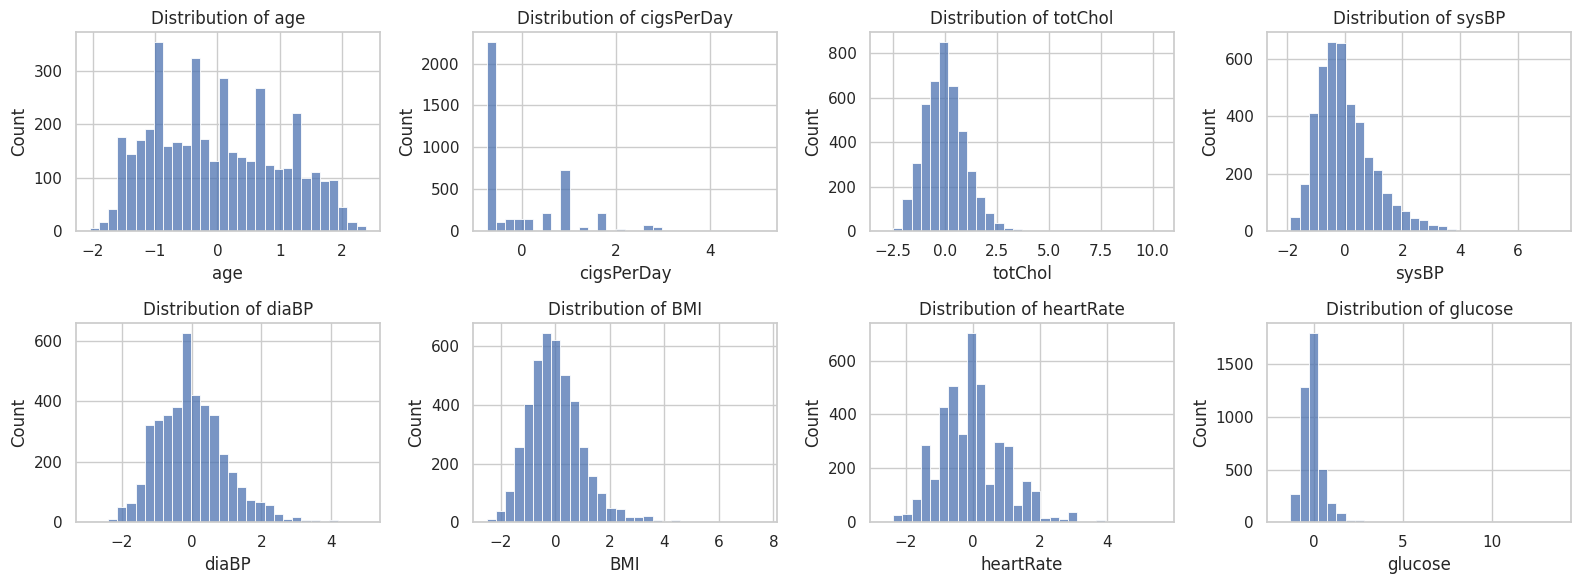

In [175]:
continuous_vars = ['age', 'cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']
scaler = StandardScaler()

df_std = df.copy()
df_std[continuous_vars] = scaler.fit_transform(df_std[continuous_vars])

columns = continuous_vars
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(16, 6))
axes = axes.flatten()
for i, col in enumerate(columns):
    sns.histplot(data=df_std, x=col, bins=30, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

In [176]:
formula = """
TenYearCHD ~ male + age + currentSmoker + cigsPerDay + BPMeds + education_2 +education_3 +education_4 +
prevalentStroke + prevalentHyp + diabetes + totChol + sysBP + diaBP +  BMI +
heartRate +
male:currentSmoker + BPMeds:prevalentStroke + prevalentHyp:currentSmoker + prevalentStroke:currentSmoker + prevalentHyp:prevalentStroke
"""

y, X = patsy.dmatrices(formula, data=df_std, return_type='dataframe')
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

significance_level = 0.05
model, selected_features = backward_selection(X_train, y_train, significance_level)

print("Variables selected by the backward selection method:")
print(selected_features)

print("\nSummary of the model after backward selection:")
print(model.summary())

print("\nPerformance comparison:")
print(f"Model backward - AIC: {model.aic:.2f}, BIC: {model.bic:.2f}")

y_pred_prob_test  = model.predict(X_test[selected_features])

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob_test)
youden_index = tpr - fpr
optimal_threshold = thresholds[np.argmax(youden_index)]
print(f"Optimal threshold: {optimal_threshold:.4f}")
y_pred_test = np.where(y_pred_prob_test >= optimal_threshold, 1, 0)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()

precision = tp / (tp + fp) if (tp + fp) != 0 else 0
recall = tp / (tp + fn) if (tp + fn) != 0 else 0
specificity = tn / (tn + fp) if (tn + fp) != 0 else 0

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Specificity: {specificity:.4f}")
print(classification_report(y_test, y_pred_test))

auc = roc_auc_score(y_test, y_pred_prob_test)
print(f'ROC AUC: {auc:.4f}')

Variables selected by the backward selection method:
['Intercept', 'male', 'age', 'cigsPerDay', 'education_2', 'diabetes', 'totChol', 'sysBP', 'prevalentHyp:prevalentStroke']

Summary of the model after backward selection:
                           Logit Regression Results                           
Dep. Variable:             TenYearCHD   No. Observations:                 2968
Model:                          Logit   Df Residuals:                     2959
Method:                           MLE   Df Model:                            8
Date:                Tue, 18 Feb 2025   Pseudo R-squ.:                  0.1214
Time:                        00:57:49   Log-Likelihood:                -1111.0
converged:                       True   LL-Null:                       -1264.6
Covariance Type:            nonrobust   LLR p-value:                 1.241e-61
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------

The standardization transformation only had the effect of altering the coefficients of the transformed variables, which became more balanced. However, it had no impact on the AIC/BIC fit or predictive capacity metrics. So there is no concrete gain from the transformation, apart from a loss in interpretability due to the change in scales.


## Model with Box-Cox Transformation

Box-Cox transformation lambdas:
age: 0.0635
totChol: -0.0129
sysBP: -1.2938
diaBP: -0.3859
BMI: -0.5741
heartRate: -0.2463
glucose: -1.3981


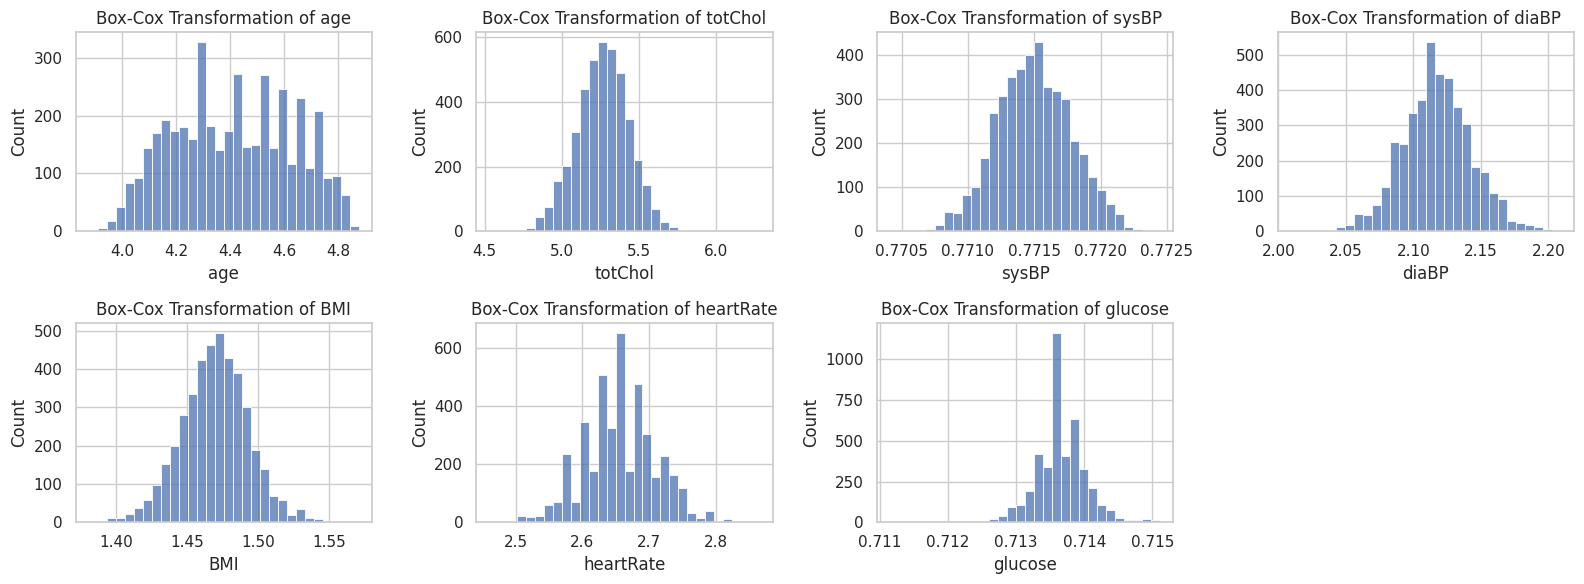

In [177]:
df_box_cox = df.copy()

boxcox_vars = ['age', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']

# Check if data is positive (Box-Cox requires positive values)
# If there are values ​​<= 0, add a minimum offset
for col in boxcox_vars:
    if (df_box_cox[col] <= 0).any():
        print(f"Values ​​<= 0 found in column {col}. Adding a minimum offset.")
        min_value = df_box_cox[col].min()
        print(f"Min value: {min_value:.2f}")
        df_box_cox[col] += abs(min_value) + 1  # Adds an offset to make all values ​​positive

boxcox_lambdas = {}
for col in boxcox_vars:
    df_box_cox[col], lambda_val = boxcox(df_box_cox[col])
    boxcox_lambdas[col] = lambda_val

print("Box-Cox transformation lambdas:")
for col, lambda_val in boxcox_lambdas.items():
    print(f"{col}: {lambda_val:.4f}")

fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(16, 6))
axes = axes.flatten()  # Flatten the axes array for easier iteration

for i, col in enumerate(boxcox_vars):
    sns.histplot(data=df_box_cox, x=col, bins=30, ax=axes[i])
    axes[i].set_title(f'Box-Cox Transformation of {col}')

if num_plots < len(axes):
    for i in range(num_plots, len(axes)):
        fig.delaxes(axes[i])


plt.tight_layout()
plt.show()

In [178]:
formula = """
TenYearCHD ~ male + age + currentSmoker + cigsPerDay + BPMeds + education_2 +education_3 +education_4 +
prevalentStroke + prevalentHyp + diabetes + totChol + sysBP + diaBP + BMI +
heartRate +
male:currentSmoker + BPMeds:prevalentStroke + prevalentHyp:currentSmoker + prevalentStroke:currentSmoker + prevalentHyp:prevalentStroke
"""

y, X = patsy.dmatrices(formula, data=df_box_cox, return_type='dataframe')
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

significance_level = 0.05
model, selected_features = backward_selection(X_train, y_train, significance_level)

print("Variables selected by the backward selection method:")
print(selected_features)

print("\nSummary of the model after backward selection:")
print(model.summary())

print("\nPerformance comparison:")
print(f"Model backward - AIC: {model.aic:.2f}, BIC: {model.bic:.2f}")

y_pred_prob_test  = model.predict(X_test[selected_features])

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob_test)
youden_index = tpr - fpr
optimal_threshold = thresholds[np.argmax(youden_index)]
print(f"Optimal threshold: {optimal_threshold:.4f}")
y_pred_test = np.where(y_pred_prob_test >= optimal_threshold, 1, 0)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()

precision = tp / (tp + fp) if (tp + fp) != 0 else 0
recall = tp / (tp + fn) if (tp + fn) != 0 else 0
specificity = tn / (tn + fp) if (tn + fp) != 0 else 0

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Specificity: {specificity:.4f}")
print(classification_report(y_test, y_pred_test))

auc = roc_auc_score(y_test, y_pred_prob_test)
print(f'ROC AUC: {auc:.4f}')

Variables selected by the backward selection method:
['Intercept', 'male', 'age', 'cigsPerDay', 'BPMeds', 'education_2', 'diabetes', 'totChol', 'sysBP', 'prevalentHyp:prevalentStroke']

Summary of the model after backward selection:
                           Logit Regression Results                           
Dep. Variable:             TenYearCHD   No. Observations:                 2968
Model:                          Logit   Df Residuals:                     2958
Method:                           MLE   Df Model:                            9
Date:                Tue, 18 Feb 2025   Pseudo R-squ.:                  0.1207
Time:                        00:57:51   Log-Likelihood:                -1112.0
converged:                       True   LL-Null:                       -1264.6
Covariance Type:            nonrobust   LLR p-value:                 2.003e-60
                                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------

Like standardization, the box cox transformation did not present gains in fit or predictive quality.
Furthermore, the transformation generated a high distortion in the coefficients, impairing interpretability.

## Model applying winsorization

>"Winsorizing or winsorization is the transformation of statistics by limiting extreme values in the statistical data to reduce the effect of possibly spurious outliers. A typical strategy to account for, without eliminating altogether, these outlier values is to 'reset' outliers to a specified percentile (or an upper and lower percentile) of the data. For example, a 90% winsorization would see all data below the 5th percentile set to the 5th percentile, and all data above the 95th percentile set to the 95th percentile."
[Wikipedia](https://en.wikipedia.org/wiki/Winsorizing)

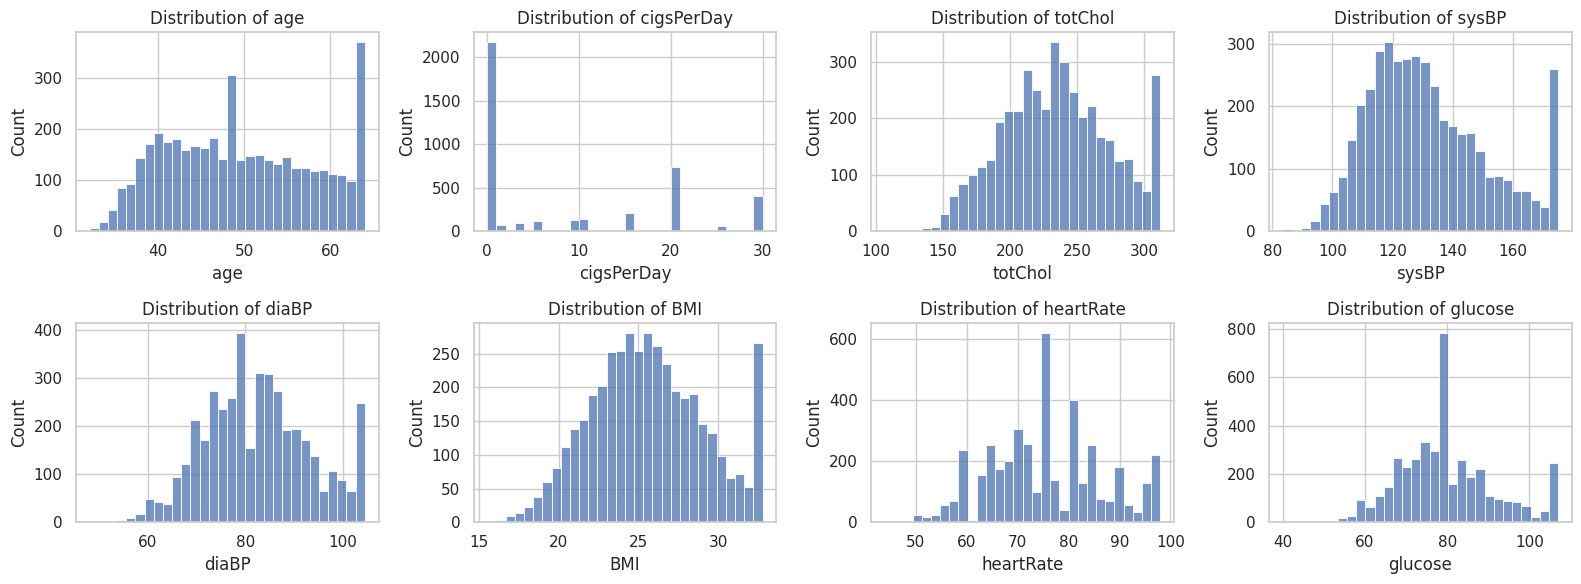

In [179]:
continuous_vars = ['age', 'cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']
def apply_winsorization(df, columns, limits=(0, 0.01)):
    for col in columns:
        df[col] = winsorize(df[col], limits=limits)
    return df

df_winsorized = df.copy()
df_winsorized = apply_winsorization(df_winsorized, continuous_vars, (0, 0.05)) # keeping lower limit as zero and changing the maximums to the 95% percentile

columns = continuous_vars
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(16, 6))
axes = axes.flatten()
for i, col in enumerate(columns):
    sns.histplot(data=df_winsorized, x=col, bins=30, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

In [180]:
formula = """
TenYearCHD ~ male + age + currentSmoker + cigsPerDay + BPMeds + education_2 +education_3 +education_4 +
prevalentStroke + prevalentHyp + diabetes + totChol + sysBP + diaBP + BMI +
heartRate +
male:currentSmoker + BPMeds:prevalentStroke + prevalentHyp:currentSmoker + prevalentStroke:currentSmoker + prevalentHyp:prevalentStroke
"""

y, X = patsy.dmatrices(formula, data=df_winsorized, return_type='dataframe')
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

significance_level = 0.05
model, selected_features = backward_selection(X_train, y_train, significance_level)

print("Variables selected by the backward selection method:")
print(selected_features)

print("\nSummary of the model after backward selection:")
print(model.summary())

print("\nPerformance comparison:")
print(f"Model backward - AIC: {model.aic:.2f}, BIC: {model.bic:.2f}")

y_pred_prob_test  = model.predict(X_test[selected_features])

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob_test)
youden_index = tpr - fpr
optimal_threshold = thresholds[np.argmax(youden_index)]
print(f"Optimal threshold: {optimal_threshold:.4f}")
y_pred_test = np.where(y_pred_prob_test >= optimal_threshold, 1, 0)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()

precision = tp / (tp + fp) if (tp + fp) != 0 else 0
recall = tp / (tp + fn) if (tp + fn) != 0 else 0
specificity = tn / (tn + fp) if (tn + fp) != 0 else 0

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Specificity: {specificity:.4f}")
print(classification_report(y_test, y_pred_test))

auc = roc_auc_score(y_test, y_pred_prob_test)
print(f'ROC AUC: {auc:.4f}')

Variables selected by the backward selection method:
['Intercept', 'male', 'age', 'cigsPerDay', 'BPMeds', 'education_2', 'diabetes', 'sysBP', 'prevalentHyp:prevalentStroke']

Summary of the model after backward selection:
                           Logit Regression Results                           
Dep. Variable:             TenYearCHD   No. Observations:                 2968
Model:                          Logit   Df Residuals:                     2959
Method:                           MLE   Df Model:                            8
Date:                Tue, 18 Feb 2025   Pseudo R-squ.:                  0.1176
Time:                        00:57:55   Log-Likelihood:                -1115.9
converged:                       True   LL-Null:                       -1264.6
Covariance Type:            nonrobust   LLR p-value:                 1.410e-59
                                   coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------

## Model removing critical values

Given that the objective is to create a model to analyze risk factors for the development of coronary disease in a broad sense, it is coherent to filter out atypical cases of extreme clinical situations, which do not well represent a typical case of a patient, such as, for example, blood pressures close to a hypertensive crisis that must be treated immediately.

Based on some medical references from institutes monitoring heart diseases and conditions, the following cutoffs were defined for some of the variables:

| BLOOD PRESSURE CATEGORY                       | SYSTOLIC mm Hg (upper number) | and/or | DIASTOLIC mm Hg (lower number) |
|-----------------------------------------------|-------------------------------|--------|-------------------------------|
| NORMAL                                        | LESS THAN 120                 | and    | LESS THAN 80                  |
| ELEVATED                                      | 120 – 129                     | and    | LESS THAN 80                  |
| HIGH BLOOD PRESSURE (HYPERTENSION) STAGE 1    | 130 – 139                     | or     | 80 – 89                       |
| HIGH BLOOD PRESSURE (HYPERTENSION) STAGE 2    | 140 OR HIGHER                 | or     | 90 OR HIGHER                  |
| HYPERTENSIVE CRISIS (consult your doctor immediately) | HIGHER THAN 180              | and/or | HIGHER THAN 120               |


Reference: [www.heart.org](https://www.heart.org/en/health-topics/high-blood-pressure/understanding-blood-pressure-readings)

Results are given in milligrams per deciliter (mg/dL). Here are the ranges for total cholesterol in adults:

- *Normal*: Less than 200 mg/dL
- *Borderline high*: 200 to 239 mg/dL
- *High*: At or above 240 mg/dL

Reference: [www.hopkinsmedicine.org](https://www.hopkinsmedicine.org/health/treatment-tests-and-therapies/lipid-panel)



>**What is a good resting heart rate?**
There is no specific good resting heart rate. Well-trained athletes can have numbers in the 40s. But a heart rate that slow for the average person would be concerning and should prompt a call to your doctor's office, especially if you felt weak, lightheaded, or short of breath.

On the other end of the scale, a resting heart rate that is consistently above 90 beats per minute is also something your doctor should be aware of. Although it is still formally still normal, it could be a clue of something amiss, but not necessarily a serious problem.

Reference: [www.health.harvard.edu](https://www.health.harvard.edu/heart-health/what-your-heart-rate-is-telling-you)


In [181]:
thresholds = {
    "sysBP": 180,
    "diaBP": 120,
    "totChol": 300,
    "heartRate": 120
}
percentiles = {}
for variable, threshold in thresholds.items():
    percentiles[variable] = percentileofscore(df[variable], threshold)
    print(f"The threshold {threshold} for {variable} corresponds to the percentile {percentiles[variable]:.2f}%")

df_filtered = df[
    (df["sysBP"] <= thresholds["sysBP"]) &
    (df["diaBP"] <= thresholds["diaBP"]) &
    (df["totChol"] <= thresholds["totChol"]) &
    (df["heartRate"] <= thresholds["heartRate"])
].copy()

The threshold 180 for sysBP corresponds to the percentile 96.14%
The threshold 120 for diaBP corresponds to the percentile 99.17%
The threshold 300 for totChol corresponds to the percentile 92.16%
The threshold 120 for heartRate corresponds to the percentile 99.74%


In [182]:
print(f"Size Delta: {round(((len(df_filtered) - len(df))*100/len(df)), 4)}%")

Size Delta: -10.8019%


In [183]:
formula = """
TenYearCHD ~ male + age + education_2 +education_3 +education_4 + currentSmoker + cigsPerDay + BPMeds +
       prevalentStroke + prevalentHyp + diabetes + totChol + sysBP +
       diaBP + BMI + heartRate + glucose
"""
y, X = patsy.dmatrices(formula, data=df_filtered, return_type='dataframe')
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

significance_level = 0.05
model, selected_features = backward_selection(X_train, y_train, significance_level)

print("Variables selected by the backward selection method:")
print(selected_features)

print("\nSummary of the model after backward selection:")
print(model.summary())

print("\nPerformance comparison:")
print(f"Model backward - AIC: {model.aic:.2f}, BIC: {model.bic:.2f}")

y_pred_prob_test  = model.predict(X_test[selected_features])

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob_test)
youden_index = tpr - fpr
optimal_threshold = thresholds[np.argmax(youden_index)]
print(f"Optimal threshold: {optimal_threshold:.4f}")
y_pred_test = np.where(y_pred_prob_test >= optimal_threshold, 1, 0)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()

precision = tp / (tp + fp) if (tp + fp) != 0 else 0
recall = tp / (tp + fn) if (tp + fn) != 0 else 0
specificity = tn / (tn + fp) if (tn + fp) != 0 else 0

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Specificity: {specificity:.4f}")
print(classification_report(y_test, y_pred_test))

auc = roc_auc_score(y_test, y_pred_prob_test)
print(f'ROC AUC: {auc:.4f}')

auc = roc_auc_score(y_test, y_pred_prob_test)
print(f'ROC AUC: {auc:.4f}')

Variables selected by the backward selection method:
['Intercept', 'male', 'age', 'education_2', 'cigsPerDay', 'prevalentStroke', 'sysBP', 'glucose']

Summary of the model after backward selection:
                           Logit Regression Results                           
Dep. Variable:             TenYearCHD   No. Observations:                 2647
Model:                          Logit   Df Residuals:                     2639
Method:                           MLE   Df Model:                            7
Date:                Tue, 18 Feb 2025   Pseudo R-squ.:                  0.1011
Time:                        00:57:55   Log-Likelihood:                -956.04
converged:                       True   LL-Null:                       -1063.6
Covariance Type:            nonrobust   LLR p-value:                 7.206e-43
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
In

## Models summary

| Model                      | Pseudo R-squ. | Log-Likelihood | AIC  | BIC  | Precision | Recall | Specificity | F1-Score | ROC AUC |
|-----------------------------|---------------|----------------|------|------|-----------|--------|-------------|----------|---------|
| Unrestricted                  | 0,1028        | -1103,7        | 2243 | 2351 | 24,6%     | 71,0%  | 61,1%       | 37,0%    | 70,1%   |
| Balanced unrestricted       | 0,1815        | -1760          | 3556 | 3664 | 24,3%     | 71,5%  | 60,2%       | 36,0%    | 70,0%   |
| Raw model with significance    | 0,1246        | -1107          | 2232 | 2286 | 26,9%     | 62,7%  | 69,5%       | 38,0%    | 70,3%   |
| Raw model with interactions        | 0,1214        | -1111          | 2240 | 2294 | 28,9%     | 57,5%  | 74,7%       | 38,0%    | 70,3%   |
| Model with interactions standardized| 0,1214        | -1111          | 2240 | 2294 | 28,9%     | 57,5%  | 74,7%       | 38,0%    | 70,3%   |
| Model with interactions box-cox    | 0,1207        | -1112          | 2244 | 2304 | 28,7%     | 59,1%  | 73,8%       | 39,0%    | 70,1%   |
| Winsorized model         | 0,1176        | -115,9           | 2250 | 2304 | 26,4%     | 65,3%  | 67,5%       | 38,0%    | 70,6%   |
| Raw model filtrado         | 0,1011        | -956           | 1928 | 1975 | 28,0%     | 67,5%  | 72,1%       | 40,0%    | 73,3%   |

For our context of application, of a preventive diagnosis, the most critical error is type II - a false negative, that is, of a person who is at risk of developing the condition but who would not be aware of it and would not take the necessary measures.

The type I error of false positives is less worrying, as this would not necessarily imply a risk to the patient, in addition to being something that can be corrected with continued medical monitoring.

Therefore, for our analysis, a good level of recall is more important for the decision


| Reality          | Positive                   | Negative              |
|------------------|----------------------------|-----------------------|
| *Study Finding Positive* | *True Positive*<br>(Power)<br>(1-β) | False Positive<br>Type I Error (α) |
| *Study Finding Negative* | False Negative<br>Type II Error (β) | *True Negative*     |


Several strategies were applied to improve the fit and interpretability of the model, including variable selection, weighting by class, addition of interactions and transformations such as standardization and Box-Cox.
Both models with standardization and transformations did not bring concrete gains and added an extra layer to the interpretation of results, without presenting performance improvements that justify the tradeoff.

The filtered model, which removes critical medical values, presented the best results in terms of AIC, BIC and ROC AUC (0.7328), as well as a better balance between specificity and recall. Removing these points likely reduced the impact of outliers, making the model more robust. Therefore, this was the approach chosen to follow as the final model.

#4.Analyzing the fit of the model

Let's keep the model on the filtered data and
the final variables:

```
['Intercept', 'male', 'age', 'education_2', 'cigsPerDay', 'prevalentStroke', 'sysBP', 'glucose']
```
And evaluate its fit to different link functions.


1. What are link functions in GLMs?
  
  In Generalized Linear Models (GLMs), the link function connects the linear prediction
  $$η=β0​+β1​X1​+⋯+βp​Xp​$$
  to the mean of the response variable μ, through a mathematical transformation.
 I.e:
  $$g(μ)=η$$
  where g is the link function.

2. Why test other link functions?
  Although the logit function is the most common choice in logistic regression models, other functions may be better suited depending on the characteristics of your data:
  - Distribution of the response variable: The logit may not capture well the relationship between the explanatory variables and the response.
  - Asymmetries in the data: If the relationship between the explanatory variables and the response is not well represented by the logit function, other functions can improve the fit.

3. Link functions that make sense in this problem
  In the context of a binary variable (`TenYearCHD`), the most common and relevant link functions are:
  - Logit (log-odds)
    - Formula: $g(μ)=ln⁡(\frac{μ}{ 1−μ})$
    - Interpretation: Relates the linear prediction η to the logarithm of the chances (odds).
    - Why use: It is the standard and widely accepted function for binary data.

  - Probit
    - Formula: $g(μ)=Φ^{-1}(μ)$, where $Φ$ is the cumulative distribution function of the standard normal.
    - Interpretation: Assumes that the probability follows a cumulative normal distribution.
    - Why use: It may be more appropriate if the relationship between the variables is smoothly increasing and symmetric.

  - Complementary Log-Log (cloglog)
    - Formula: $g(μ)=ln⁡(−ln⁡(1−μ))$
    - Interpretation: It is more sensitive to asymmetries, as it models cases in which extreme events (probabilities very close to 0 or 1) are more likely.
    - Why use: If there are strong asymmetries in the data or if the events of interest (developing CHD) are rare.

In [184]:
formula = """
TenYearCHD ~ male + age + education_2 + cigsPerDay + prevalentStroke + sysBP + glucose
"""

y, X = patsy.dmatrices(formula, data=df_filtered, return_type='dataframe')
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

links = {
    'logit': Logit(),
    'probit': Probit(),
    'cloglog': CLogLog()
}

models = {}
for name, link in links.items():
  print(f"Adjusting model with link function: {name}")
  model = sm.GLM(y_train, X_train, family=Binomial(link=link)).fit()
  models[name] = model
  print(model.summary())
  print(f"Model - AIC: {model.aic:.2f}, BIC: {model.bic_llf:.2f}") # Using bic_llf

Adjusting model with link function: logit
                 Generalized Linear Model Regression Results                  
Dep. Variable:             TenYearCHD   No. Observations:                 2647
Model:                            GLM   Df Residuals:                     2639
Model Family:                Binomial   Df Model:                            7
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -956.04
Date:                Tue, 18 Feb 2025   Deviance:                       1912.1
Time:                        00:57:56   Pearson chi2:                 2.66e+03
No. Iterations:                     6   Pseudo R-squ. (CS):            0.07805
Covariance Type:            nonrobust                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------


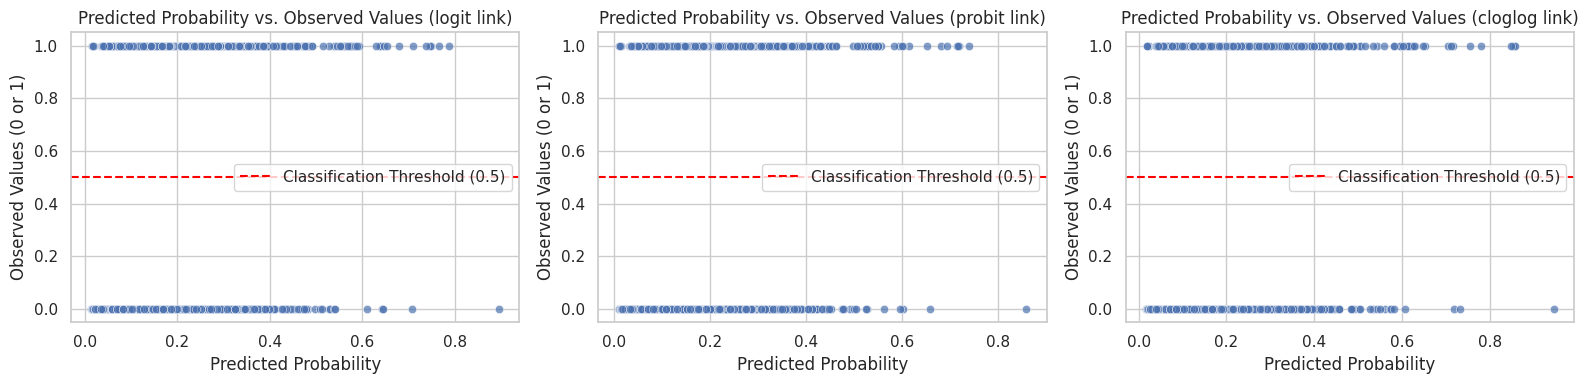

In [185]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for i, (name, model) in enumerate(models.items()):
    prob_predicted = model.predict(X)

    sns.scatterplot(x=prob_predicted, y=y.iloc[:, 0], alpha=0.7, ax=axes[i])
    axes[i].axhline(0.5, color='red', linestyle='--', label="Classification Threshold (0.5)")
    axes[i].set_title(f"Predicted Probability vs. Observed Values ​​({name} link)")
    axes[i].set_xlabel("Predicted Probability")
    axes[i].set_ylabel("Observed Values (0 or 1)")
    axes[i].legend()

plt.tight_layout()
plt.show()

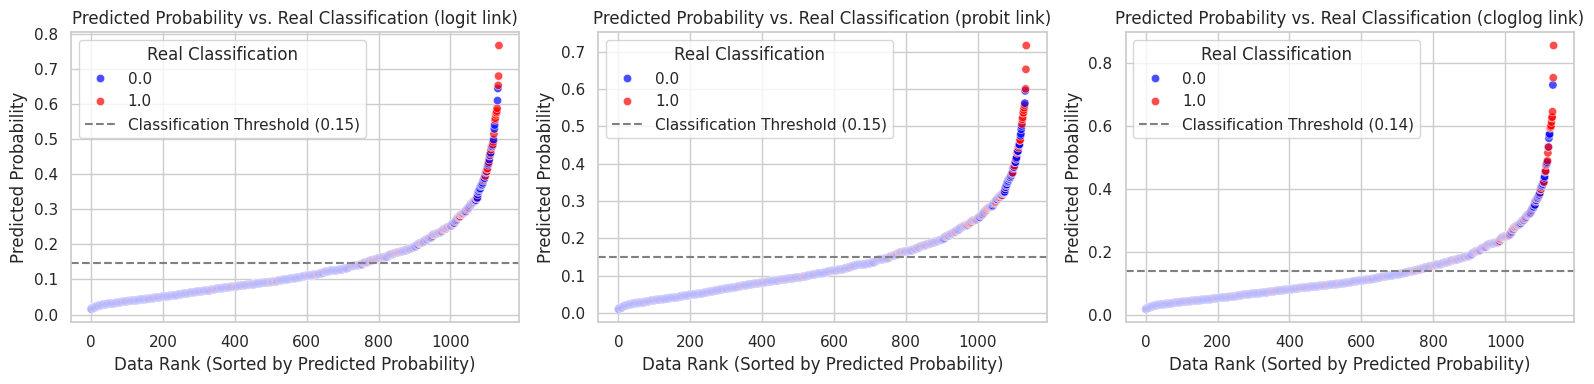

In [186]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for i, (name, model) in enumerate(models.items()):
    y_pred_prob_test = model.predict(X_test)
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob_test)
    youden_index = tpr - fpr
    optimal_threshold = thresholds[np.argmax(youden_index)]
    y_pred_test = np.where(y_pred_prob_test >= optimal_threshold, 1, 0)


    df_plot = pd.DataFrame({'prob_predicted': y_pred_prob_test, 'TenYearCHD': y_test['TenYearCHD'].values})
    df_plot = df_plot.sort_values(by=['prob_predicted']).reset_index(drop=True)
    df_plot['rank'] = df_plot.index + 1

    sns.scatterplot(x='rank', y='prob_predicted', hue='TenYearCHD', data=df_plot, alpha=0.7, palette={0: 'blue', 1: 'red'},  ax=axes[i])
    axes[i].axhline(optimal_threshold, color='gray', linestyle='--', label=f"Classification Threshold ({optimal_threshold:.2f})")
    axes[i].set_title(f"Predicted Probability vs. Real Classification ({name} link)")
    axes[i].set_xlabel("Data Rank (Sorted by Predicted Probability)")
    axes[i].set_ylabel("Predicted Probability")
    axes[i].legend(title="Real Classification", loc="upper left")

plt.tight_layout()
plt.show()

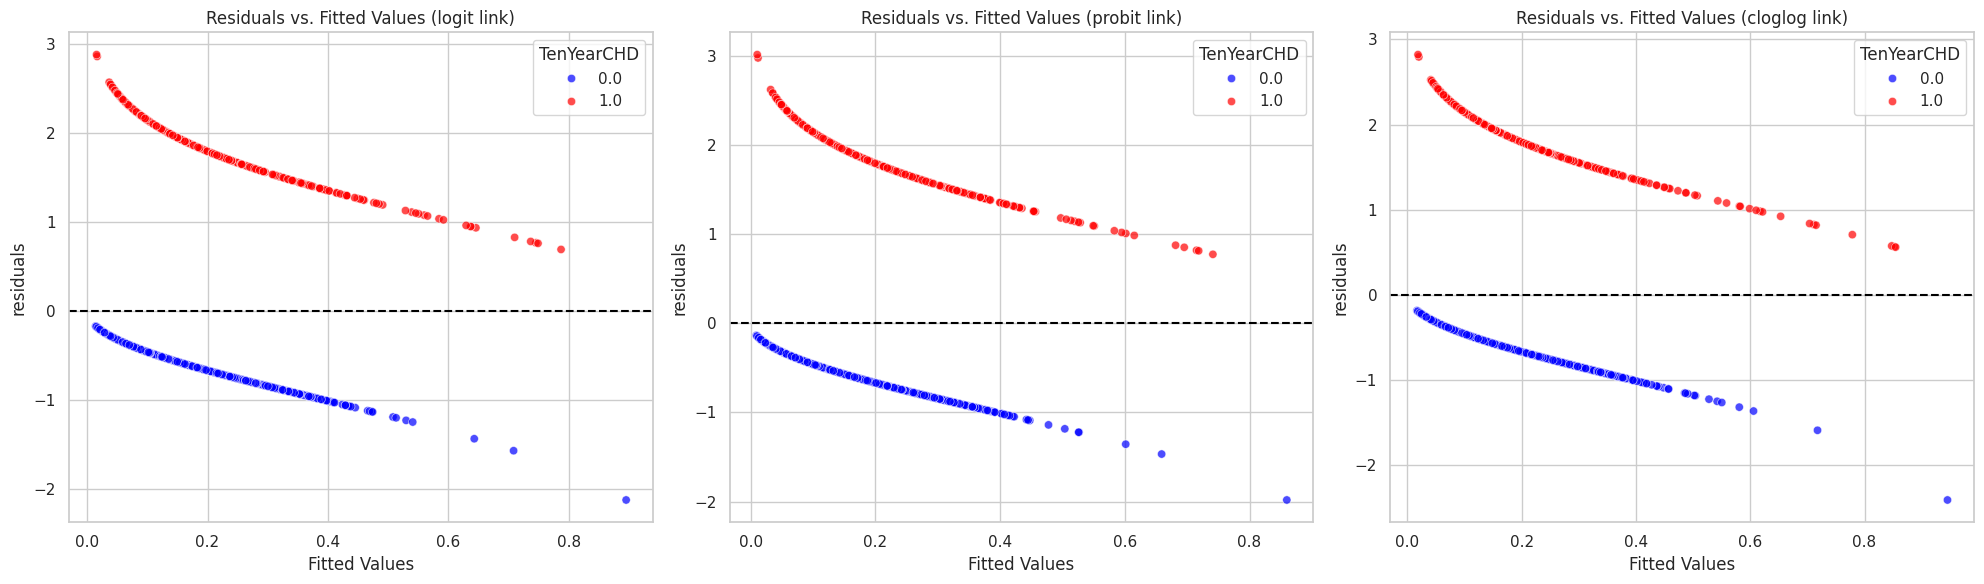

In [187]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, (name, model) in enumerate(models.items()):
    residuals = model.resid_deviance

    df_plot = pd.DataFrame({'fittedvalues': model.fittedvalues, 'residuals': residuals, 'TenYearCHD': y_train.iloc[:, 0]})

    sns.scatterplot(x='fittedvalues', y='residuals', hue='TenYearCHD', data=df_plot,
                    alpha=0.7, palette={0: 'blue', 1: 'red'}, ax=axes[i])
    axes[i].axhline(0, color='black', linestyle='--')
    axes[i].set_title(f"Residuals vs. Fitted Values ({name} link)")
    axes[i].set_xlabel("Fitted Values")
    axes[i].set_ylabel("residuals")
    axes[i].legend(title="TenYearCHD")

plt.tight_layout()
plt.show()

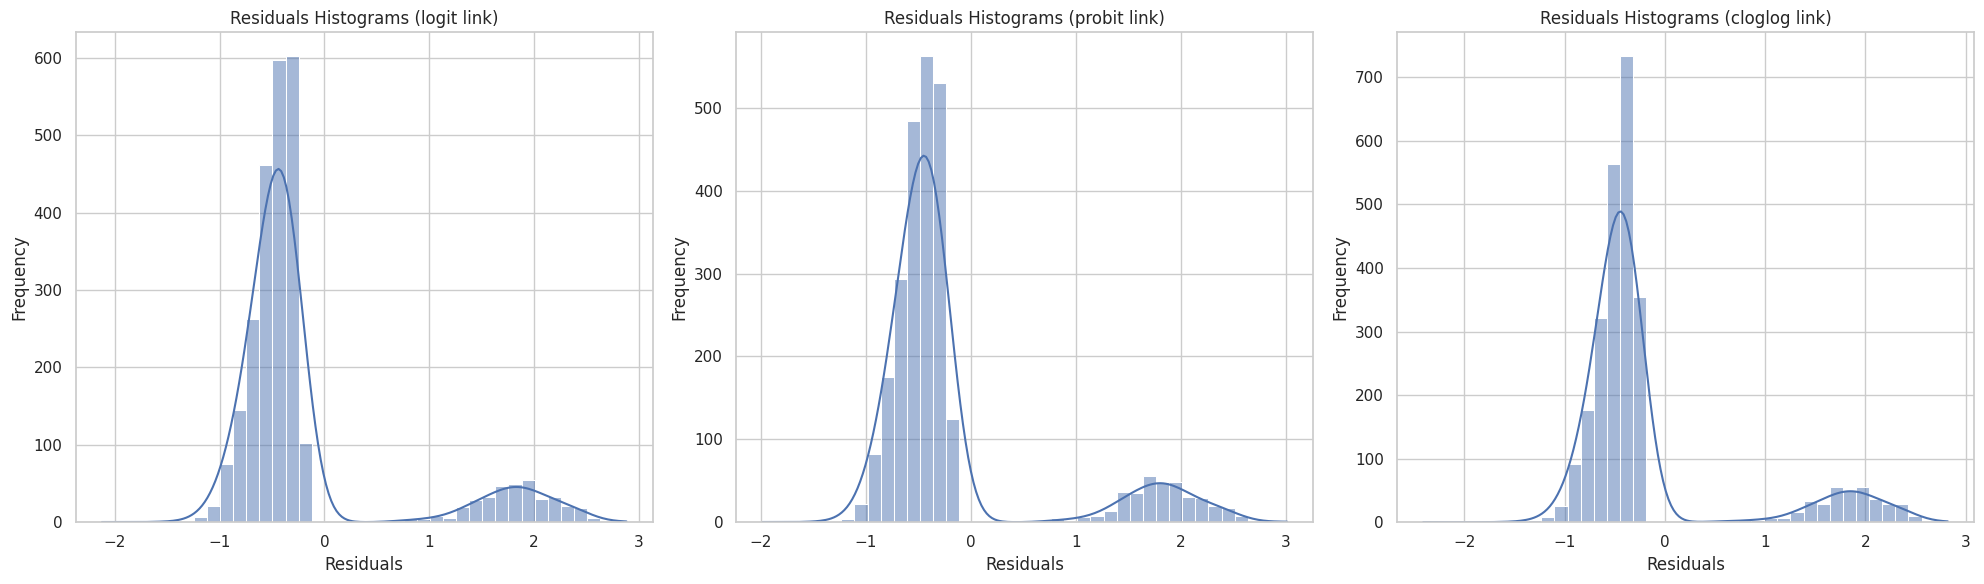

In [188]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))  # 1 row, 3 columns

for i, (name, model) in enumerate(models.items()):
    residuals = model.resid_deviance

    sns.histplot(residuals, kde=True, bins=40, ax=axes[i])
    axes[i].set_title(f"Residuals Histograms ({name} link)")
    axes[i].set_xlabel("Residuals")
    axes[i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

For a good fit, the distribution of residuals should be approximately symmetric and centered around 0.

Bimodal behavior (two peaks) indicates that the residuals do not follow an expected normal distribution.
This could mean that there are distinct groups in the data that the model was unable to adequately capture.

Potential problems:
- Heteroscedasticity: The variance of the residuals may not be constant, indicating that the model is adjusting better for some ranges of values ​​and worse for others.

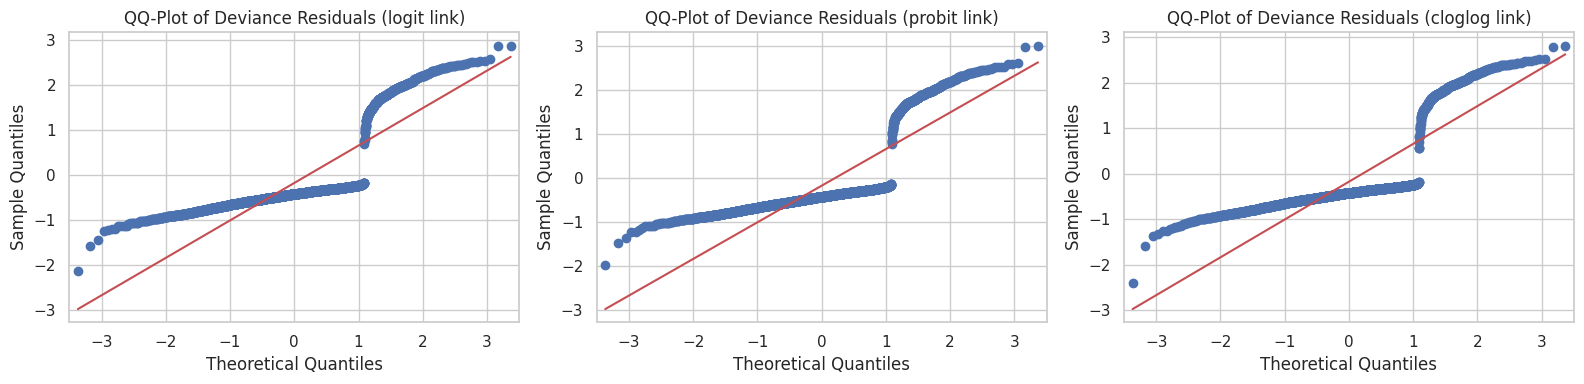

In [189]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))  # 1 row, 3 columns

for i, (name, model) in enumerate(models.items()):
    residuals = model.resid_deviance

    sm.qqplot(residuals, line='s', ax=axes[i])
    axes[i].set_title(f"QQ-Plot of Deviance Residuals ({name} link)")

plt.tight_layout()
plt.show()

The QQ-plot (Quantile-Quantile Plot) is a graphical tool used to compare the distribution of residuals (or any set of data) with an expected theoretical distribution, usually the normal distribution.
- X-axis (Theoretical Quantiles): Represents the quantiles of the theoretical distribution (e.g., normal).
- Y axis (Sample Quantiles): Represents the quantiles observed in the data.

If the data follows the expected theoretical distribution:
The QQ-plot points should form a straight line close to the red (diagonal) line.

In this case:
1. Curvature at the ends:
  The graphs show curvatures in the tails, with the points moving significantly away from the red line. This suggests that the residuals do not follow a normal distribution, especially at the extremes.
2. Center Targeting:
  There is a sort of separation or "plateau" in the center of the graph. This may indicate distinct groups of data or that the modeled relationship does not capture some characteristics of the data well.
3. Practical impact:
  The observed pattern may suggest that the model is violating the assumption of normality of residuals.
  Another possibility is that the variability of the data (or the dispersion of the residuals) is not being fully explained by the current model.

#5.Interpreting the Model

---

Despite the modest quality of the model fit - which we have seen from previous analyzes to be suboptimal. I would like to explore the direct interpretability that the logistic model provides through coefficients as changes in odds ratios.

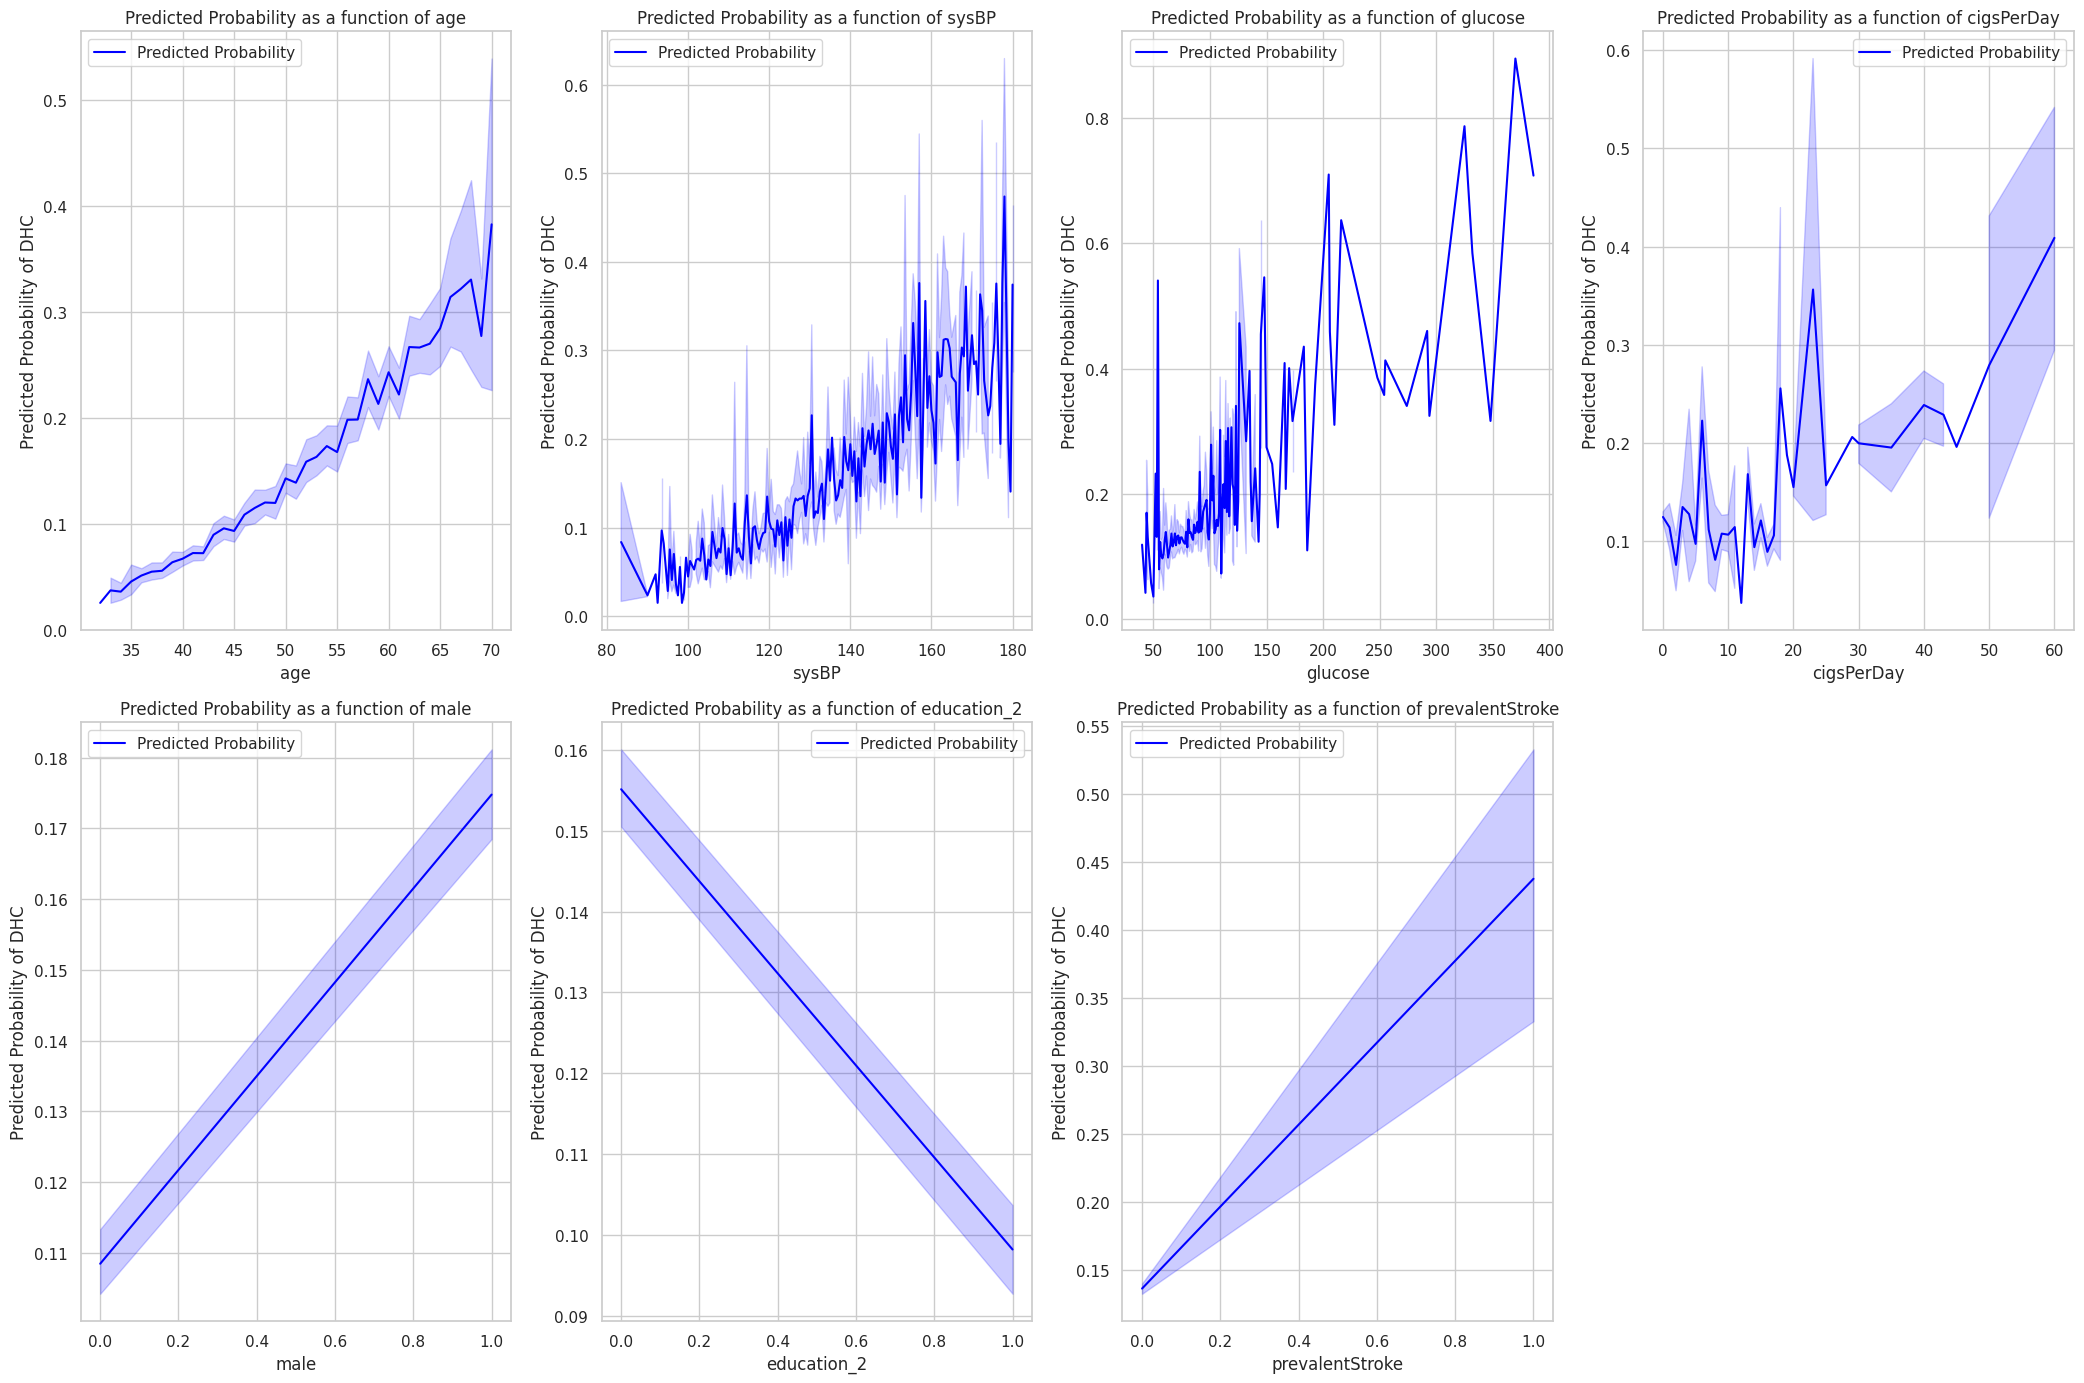

In [190]:
predictor_vars = ['age', 'sysBP', 'glucose', 'cigsPerDay', 'male', 'education_2',  'prevalentStroke']
prob_predicted = models['logit'].predict(X_train)

num_rows = 2
num_cols = 4
fig, axes = plt.subplots(num_rows, num_cols, figsize=(21, 14))

for i, var in enumerate(predictor_vars):
    row = i // num_cols
    col = i % num_cols
    ax = axes[row, col]

    sns.lineplot(x=X_train[var], y=prob_predicted, label="Predicted Probability", color='blue', ax=ax)
    ax.set_title(f"Predicted Probability as a function of {var}")
    ax.set_xlabel(var)
    ax.set_ylabel("Predicted Probability of DHC")
    ax.legend()

for i in range(len(predictor_vars), num_rows * num_cols):
    fig.delaxes(axes[i // num_cols, i % num_cols])

plt.tight_layout()
plt.show()

1. Well-established risk factors:

  Variables such as age and sysBP demonstrate a progressive and well-defined increase in the probability of CHD, reinforcing findings already known in the medical literature about the impacts of aging and hypertension on cardiovascular health.

2. Effect of Stroke History:

  The variable prevalentStroke shows a significant effect, with individuals who have already had a stroke showing a higher predicted probability of CHD. This suggests that previous cardiovascular conditions are a strong predictor of the disease.

3. Glucose and smoking behavior:

  *Increased glucose levels appear to be associated with a greater likelihood of CHD, but variability in the data indicates that there may be a more complex behavior, perhaps mediated by factors such as diabetes and lifestyle. Note that in this range of values ​​the volume of data is smaller, which also increases the uncertainty of the measurement.
  * Cigarette consumption (cigsPerDay) is also correlated with a higher risk, especially for higher values, but with greater statistical uncertainty due to the smaller sample volume.

4. Role of education and gender:

  * Individuals with an education_2 educational level have a lower predicted probability of CHD, suggesting that socioeconomic factors may play a protective role.
  * Men tend to have a slightly higher risk of CHD, which may be related to hormonal, behavioral factors or history of exposure to risky habits.

**Chances x Probabilities**

The odds in favor of my team winning the game are 1 to 4

In this example, we would have a total of 5 games, one of which my team would win and four of which my team would lose.

Odds are not probabilities, they are a ratio between something that happens (i.e. my team wins) and something that doesn't happen (i.e. my team doesn't win)

Probability is the ratio between something that could happen (i.e., my team wins) and everything that would be possible to happen (i.e., my team wins and loses).

The odds can be calculated using the odds ratio:

$$ \frac{\text{probability of winning}}{\text{probability of losing}} \\
=
\frac{\text{probability of winning}}{\text{1 - probability of winning}}\\
= \frac{p}{(1-p)}
$$

The behavior of the chances is asymmetric, when we say that the chances of an event are low (example of the game of 1 to 4), its value will be a number in the interval $[0,1)$.

When the odds are positive (2 to 1) the chances will assume a value between 1 and infinity.

To correct the asymmetry and facilitate analysis, it is common to apply the logarithm of the odds "*Log Odds Ratio*", also known as the *logit* function. The logit can increase to positive infinity as the odds are in favor of the observed event and, on the other hand, decrease to negative infinity if the odds are against the event.

In [191]:
coefficients = models['logit'].params[1:]
selected_features = models['logit'].model.exog_names[1:]
coef_df = pd.DataFrame({
    'Feature': selected_features,
    'Coefficients': coefficients,
    'Odds Ratio': np.exp(coefficients)
})

coef_df = coef_df.sort_values(by='Coefficients', ascending=False)
print(coef_df)

                         Feature  Coefficients  Odds Ratio
prevalentStroke  prevalentStroke      1.207538    3.345239
male                        male      0.373721    1.453132
age                          age      0.059137    1.060921
cigsPerDay            cigsPerDay      0.025515    1.025843
sysBP                      sysBP      0.019477    1.019668
glucose                  glucose      0.008224    1.008258
education_2          education_2     -0.312967    0.731274


**1. Odds Ratio (OR): What does it mean?**

- The OR measures how much an increase of one unit in a variable increases (or reduces) the chance of an event occurring.
- OR > 1: Increases the chance of the event (risk factor).
- OR < 1: Reduces the chance of the event (protective factor).
- OR = 1: There is no impact on the probability of the event.
The coefficient in the model is the natural logarithm of the OR, that is:

$$OR = e ^{\text{Coefficient}}$$

1. Factors with the greatest impact:

  * Stroke history (prevalentStroke): OR = 3.35

    → Individuals who have already had a stroke have more than 3 times the chance of developing CHD compared to those who have not.
    
    
  * Male: OR = 1.45
    
    → Men have a 45% increase in the chance of CHD compared to women.
    
2. Impact of aging and known risk factors:

  * Age: OR = 1.06

    → For each additional year of age, the chance of CHD increases by 6%.

    → Small unitary effect, but with significant cumulative impact over time.
  * Systolic blood pressure (sysBP): OR = 1.02
    
    → Each additional point in systolic blood pressure increases the chance of CHD by 2%.

  * Glucose (glucose): OR = 1.008
    
    → Small unit effect (0.8% per glucose point), but relevant, especially for higher values.

3. Behavioral factors:

  * Cigarettes per day (cigsPerDay): OR = 1.025

    → Each additional cigarette increases the chance of CHD by 2.5%.

    → Small unitary effect, but heavy smokers accumulate a large risk. A pack of cigarettes has an average of 20 units, which would indicate an increase of 50% per pack/day

4. Protective factors:

  * Educational level (education_2): OR = 0.73
    
    → Individuals with this educational level have a 27% lower chance of CHD.
    
    → Possible effect of greater knowledge about health and access to better medical care.

#6.Reading Suggestions
---

* [SMOTE: Synthetic Minority Over-sampling Technique](https://arxiv.org/pdf/1106.1813)
* [Google ML Crash Course](https://developers.google.com/machine-learning/crash-course/classification/accuracy-precision-recall)
* [An Introduction to Statistical Learning](https://www.statlearning.com/)
* [R-Project](https://cran.r-project.org/web/packages/sjPlot/vignettes/plot_interactions.html)
* [LOESS plot](https://en.wikipedia.org/wiki/Local_regression)
* [Youden's J statistic](https://en.wikipedia.org/wiki/Youden%27s_J_statistic)
* [Odds and Log(Odds), Clearly Explained!!!](https://youtu.be/ARfXDSkQf1Y)
* [Over Samplig Practical Guide Sklearn](https://imbalanced-learn.org/stable/over_sampling.html#)

# Extra: Avaliando técnica de oversampling SMOTE
---

>Synthetic Minority Oversampling Technique (SMOTE) is a statistical technique for increasing the number of cases in your dataset in a balanced way. The component works by generating new instances from existing minority cases that you supply as input. This implementation of SMOTE does not change the number of majority cases.

>The new instances are not just copies of existing minority cases. Instead, the algorithm takes samples of the feature space for each target class and its nearest neighbors. The algorithm then generates new examples that combine features of the target case with features of its neighbors. This approach increases the features available to each class and makes the samples more general.

[learn.microsoft](https://learn.microsoft.com/en-us/azure/machine-learning/component-reference/smote?view=azureml-api-2)

We will continue in this case with the Sklearn package for implementation and variable selection.
We will apply the SMOTE method to improve class balancing in the data and evaluate possible gains in predictive capacity

Separate the data first and treat training and testing and then apply the transformations only to the training set. The test set is transformed using the parameters calculated in training.

**Advantages**:
- Prevents information leakage: Parameters such as mean and standard deviation are calculated only on the training set, simulating the real-world scenario where the test data is unknown.
- Realistic evaluation: The model's performance reflects its generalization capacity.

In [192]:
df = pd.read_csv(path+'/framingham.csv')
df = create_dummies(df, categorical_vars_with_dummies=['education'])
df = df.rename(columns={
    'education_2.0': 'education_2',
    'education_3.0': 'education_3',
    'education_4.0': 'education_4'
})

X = df.drop(columns=["TenYearCHD"])
y = df["TenYearCHD"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)


numeric_cols = ['age', 'cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']
categorical_cols = ['BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes', 'currentSmoker', 'male']


numeric_imputer = SimpleImputer(strategy='median')
X_train[numeric_cols] = numeric_imputer.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = numeric_imputer.transform(X_test[numeric_cols])

categorical_imputer = SimpleImputer(strategy='most_frequent')
X_train[categorical_cols] = categorical_imputer.fit_transform(X_train[categorical_cols])
X_test[categorical_cols] = categorical_imputer.transform(X_test[categorical_cols])

smote = SMOTE(sampling_strategy="auto", random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Helped in the convergence of the algorithm
scaler = StandardScaler()
X_train_resampled = scaler.fit_transform(X_train_resampled)
X_test = scaler.transform(X_test)

In [193]:
y_train_resampled.value_counts(normalize=True)

,proportion
TenYearCHD,
0,0.5
1,0.5


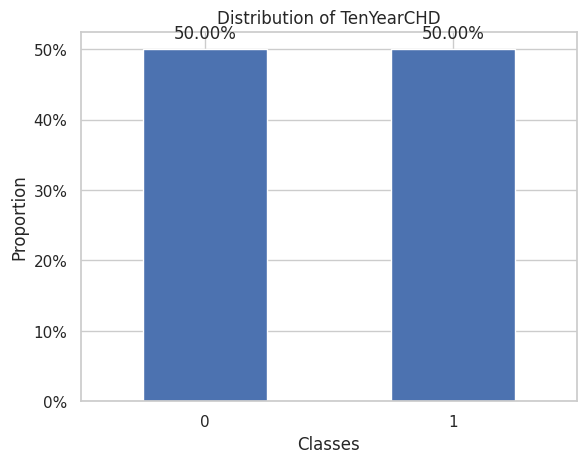

In [194]:
class_proportions = y_train_resampled.value_counts(normalize=True)
ax = class_proportions.plot(kind='bar', rot=0)
for p in ax.patches:
  height = p.get_height()
  ax.annotate(f'{height:.2%}', (p.get_x() + p.get_width() / 2., height),
              ha='center', va='bottom', xytext=(0, 5), textcoords='offset points')

ax.set_title('Distribution of TenYearCHD')
ax.set_xlabel('Classes')
ax.set_ylabel('Proportion')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.show()

In [195]:
model = LogisticRegression(random_state=42, penalty='l1', solver='saga')
model.fit(X_train_resampled, y_train_resampled)

LogisticRegression(penalty='l1', random_state=42, solver='saga')

In [196]:
y_pred_prob_test  = model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob_test)
youden_index = tpr - fpr
optimal_threshold = thresholds[np.argmax(youden_index)]
print(f"Optimal threshold: {optimal_threshold:.4f}")

y_pred_test = np.where(y_pred_prob_test >= optimal_threshold, 1, 0)


tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()

precision = tp / (tp + fp) if (tp + fp) != 0 else 0
recall = tp / (tp + fn) if (tp + fn) != 0 else 0
specificity = tn / (tn + fp) if (tn + fp) != 0 else 0

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Specificity: {specificity:.4f}")
print(classification_report(y_test, y_pred_test))

Optimal threshold: 0.5088
Precision: 0.2500
Recall: 0.5389
Specificity: 0.7108
              precision    recall  f1-score   support

           0       0.90      0.71      0.79      1079
           1       0.25      0.54      0.34       193

    accuracy                           0.68      1272
   macro avg       0.57      0.62      0.57      1272
weighted avg       0.80      0.68      0.72      1272



No significant gains over the unconstrained model:

```
              precision    recall  f1-score   support

         0.0       0.92      0.61      0.73      1079
         1.0       0.25      0.71      0.37       193

    accuracy                           0.63      1272
   macro avg       0.58      0.66      0.55      1272
weighted avg       0.82      0.63      0.68      1272

```
There was only one recall reduction

In [197]:
coefficients = model.coef_
feature_names = X_train.columns
for feature, coef in zip(feature_names, coefficients[0]): # coefficients[0] to access the first row
    print(f"{feature}: {coef:.4f}")

male: 0.1669
age: 0.5473
currentSmoker: -0.0242
cigsPerDay: 0.3209
BPMeds: 0.1405
prevalentStroke: 0.1316
prevalentHyp: 0.1277
diabetes: -0.0577
totChol: 0.1632
sysBP: 0.0899
diaBP: 0.1412
BMI: -0.0395
heartRate: -0.0824
glucose: 0.2335
education_2: -0.7403
education_3: -0.5763
education_4: -0.4440


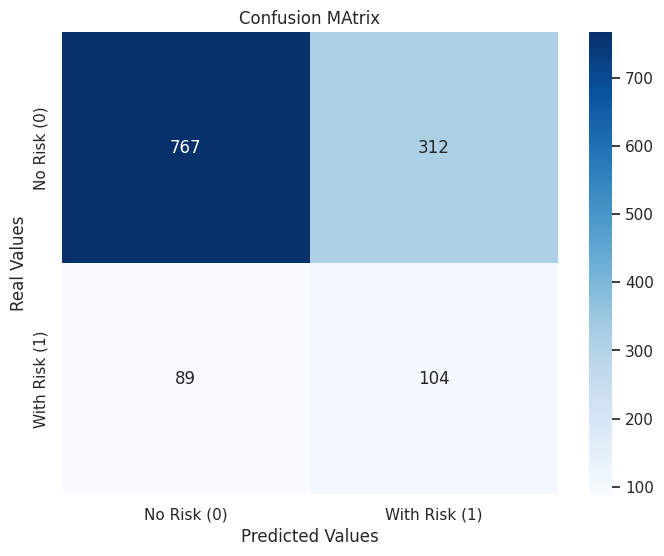

In [198]:
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_test), annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Risk (0)", "With Risk (1)"],
            yticklabels=["No Risk (0)", "With Risk (1)"])
plt.xlabel("Predicted Values")
plt.ylabel("Real Values")
plt.title("Confusion MAtrix")
plt.show()

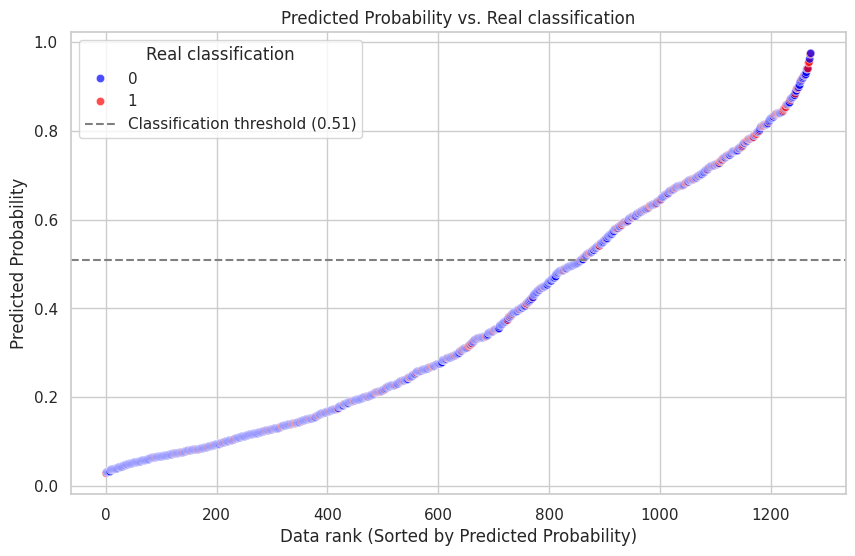

In [199]:
df_plot = pd.DataFrame({'prob_predicted': y_pred_prob_test, 'TenYearCHD': y_test.values})
df_plot = df_plot.sort_values(by=['prob_predicted']).reset_index(drop=True)
df_plot['rank'] = df_plot.index + 1  # Adicionar coluna de rank (começando em 1)

plt.figure(figsize=(10, 6))
sns.scatterplot(x='rank', y='prob_predicted', hue='TenYearCHD', data=df_plot, alpha=0.7, palette={0: 'blue', 1: 'red'})

plt.axhline(optimal_threshold, color='gray', linestyle='--', label=f"Classification threshold ({optimal_threshold:.2f})")  # Linha de corte
plt.title("Predicted Probability vs. Real classification")
plt.xlabel("Data rank (Sorted by Predicted Probability)")
plt.ylabel("Predicted Probability")
plt.legend(title="Real classification", loc="upper left")
plt.show()

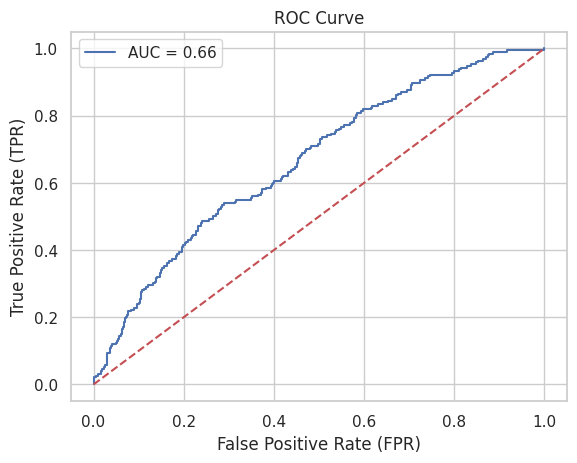

In [200]:
# Variáveis reais e predições
y_true = y_test.values  # Substitua pelo nome da sua variável dependente

# Calculando a curva ROC
fpr, tpr, thresholds = roc_curve(y_true, y_pred_prob_test)
auc = roc_auc_score(y_true, y_pred_prob_test)

# Plot
plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
plt.plot([0, 1], [0, 1], 'r--')  # Linha de referência
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve")
plt.legend()
plt.show()


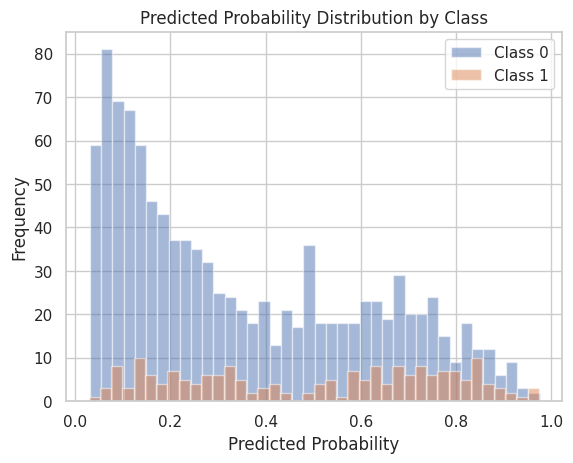

In [201]:
plt.hist(y_pred_prob_test[y_true == 0], bins=40, alpha=0.5, label="Class 0")
plt.hist(y_pred_prob_test[y_true == 1], bins=40, alpha=0.5, label="Class 1")
plt.xlabel("Predicted Probability")
plt.ylabel("Frequency")
plt.title("Predicted Probability Distribution by Class")
plt.legend()
plt.show()


## Cross Validation
---
Evaluate model stability with different test and training sets

In [202]:
y_train_ravel = y_train_resampled.values.ravel()

# Cross validation (5 folds)
cv_scores = cross_val_score(model, X_train_resampled, y_train_ravel, cv=5, scoring='roc_auc')

print(f"AUC by fold: {cv_scores}")
print(f"AUC avg: {cv_scores.mean():.3f}")
print(f"Std Dev of AUC: {cv_scores.std():.3f}")

AUC by fold: [0.68432658 0.82789769 0.85565575 0.8156892  0.84268544]
AUC avg: 0.805
Std Dev of AUC: 0.062



## Usando o modelo filtrado com as varíaveis significativas
## Using the filtered model with significant variables

In [203]:
X = df_filtered[['male', 'age', 'education_2', 'cigsPerDay', 'prevalentStroke', 'sysBP', 'glucose']]
y = df_filtered["TenYearCHD"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

smote = SMOTE(sampling_strategy="auto", random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

scaler = StandardScaler()
X_train_resampled = scaler.fit_transform(X_train_resampled)
X_test = scaler.transform(X_test)

In [204]:
model = LogisticRegression(random_state=42)
model.fit(X_train_resampled, y_train_resampled)

LogisticRegression(random_state=42)

In [205]:
y_pred_prob_test  = model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob_test)
youden_index = tpr - fpr
optimal_threshold = thresholds[np.argmax(youden_index)]
print(f"Optimal threshold: {optimal_threshold:.4f}")

y_pred_test = np.where(y_pred_prob_test >= optimal_threshold, 1, 0)


tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()

precision = tp / (tp + fp) if (tp + fp) != 0 else 0
recall = tp / (tp + fn) if (tp + fn) != 0 else 0
specificity = tn / (tn + fp) if (tn + fp) != 0 else 0

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Specificity: {specificity:.4f}")
print(classification_report(y_test, y_pred_test))

Optimal threshold: 0.5179
Precision: 0.2189
Recall: 0.5605
Specificity: 0.6789
              precision    recall  f1-score   support

           0       0.91      0.68      0.78       978
           1       0.22      0.56      0.31       157

    accuracy                           0.66      1135
   macro avg       0.56      0.62      0.55      1135
weighted avg       0.81      0.66      0.71      1135



In [206]:
y_train_ravel = y_train_resampled.values.ravel()
cv_scores = cross_val_score(model, X_train_resampled, y_train_ravel, cv=5, scoring='roc_auc')

print(f"AUC by fold: {cv_scores}")
print(f"AUC avg: {cv_scores.mean():.3f}")
print(f"Std Dev of AUC: {cv_scores.std():.3f}")

AUC by fold: [0.69014166 0.77350378 0.75527085 0.77164608 0.76990516]
AUC avg: 0.752
Std Dev of AUC: 0.032
